### Слайд 3. Биологический нейрон vs искусственный нейрон
Искусственный нейрон — это сильно упрощенная, но обучаемая математическая копия биологического.

### Слайд 4. Математическая модель перцептрона

Что такое bias простыми словами?
Функция 
w^T*x + b — это уравнение прямой в многомерном пространстве.
Bias сдвигает границу решения относительно нуля.

Пример:

Без bias нейрон может разделить только прямые, проходящие через начало координат (жестко)

С bias — любые прямые

Итог: bias увеличивает выразительность модели.

In [1]:
import numpy as np

class Perceptron:
    """
    Простейший искусственный нейрон
    """

    def __init__(self,n_inputs,activation = 'step'):
        # Инициализация весов маленькими случайными числами
        self.weights = np.random.randn(n_inputs)*0.1
        self.bias = 0.0
        self.activation = activation

    def activate(self,x):
        """Функции активации"""
        if self.activation == 'step':
            # Пороговая функция: 1 если >= 0, иначе 0
            return 1 if x>=0 else 0
        elif self.activation == 'sigmoid':
            # Сигмоида (будем использовать позже)
            return 1 / (1 + np.exp(-x))
        else:
            return x
        
    def forward(self,inputs):
        """Прямой проход: сумма -> активация"""
        z = np.dot(inputs,self.weights) + self.bias
        return self.activate(z)
    
    def set_weights_manually(self,weights,bias):
        """Для ручной настройки весов (как ты предложил)"""
        self.weights = np.array(weights)
        self.bias = bias

In [34]:
# -------------------------------------------------
# Пример: решение идти на улицу или нет
# -------------------------------------------------

# Признаки: [температура, дождь]
# Температура: 0=холодно, 1=тепло
# Дождь: 0=нет, 1=да

# Твоя ручная настройка весов
neuron = Perceptron(n_inputs=3)
neuron.set_weights_manually(weights=[2,-3,3],bias = 0.5)

In [35]:
print("=" * 50)
print("Нейрон 'Идти на улицу?' (ручная настройка)")
print("=" * 50)

# Тестовые ситуации
test_cases = [
    ([1, 0,0], "Тепло, без дождя, нет зонта"),
    ([1, 1,1 ], "Тепло, дождь, есть зонт"),
    ([0, 0,0], "Холодно, без дождя, нет зонта"),
    ([0, 1,0], "Холодно, дождь, нет зонта"),
    ([0, 1,1], "Холодно, дождь, есть зонт"),
]

for inputs, description in test_cases:
    result = neuron.forward(inputs)
    decision = "✅ Идём" if result == 1 else "❌ Сидим дома"
    print(f"{description:20} -> {decision}")

Нейрон 'Идти на улицу?' (ручная настройка)
Тепло, без дождя, нет зонта -> ✅ Идём
Тепло, дождь, есть зонт -> ✅ Идём
Холодно, без дождя, нет зонта -> ✅ Идём
Холодно, дождь, нет зонта -> ❌ Сидим дома
Холодно, дождь, есть зонт -> ✅ Идём


### Слайд 9: Классические функции активации

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class ActivationFunctions:
    """Реализация всех основных функций активации"""
    
    # Это декоратор Python, который говорит: "Этот метод принадлежит классу, но не требует создания объекта".
    @staticmethod
    def step(x):
        """Пороговая функция (Маккалок-Питтс)"""
        return np.where(x >= 0, 1, 0)
    
    @staticmethod
    def sigmoid(x):
        """Сигмоида: гладкая, выход (0, 1)"""
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))  # clip для защиты от переполнения
    
    @staticmethod
    def tanh(x):
        """Гиперболический тангенс: выход (-1, 1)"""
        return np.tanh(x)
    
    @staticmethod
    def relu(x):
        """ReLU: просто и эффективно"""
        return np.maximum(0, x)
    
    @staticmethod
    def leaky_relu(x, alpha=0.01):
        """Leaky ReLU: решает проблему "мертвых" нейронов"""
        return np.where(x >= 0, x, alpha * x)

Matplotlib is building the font cache; this may take a moment.


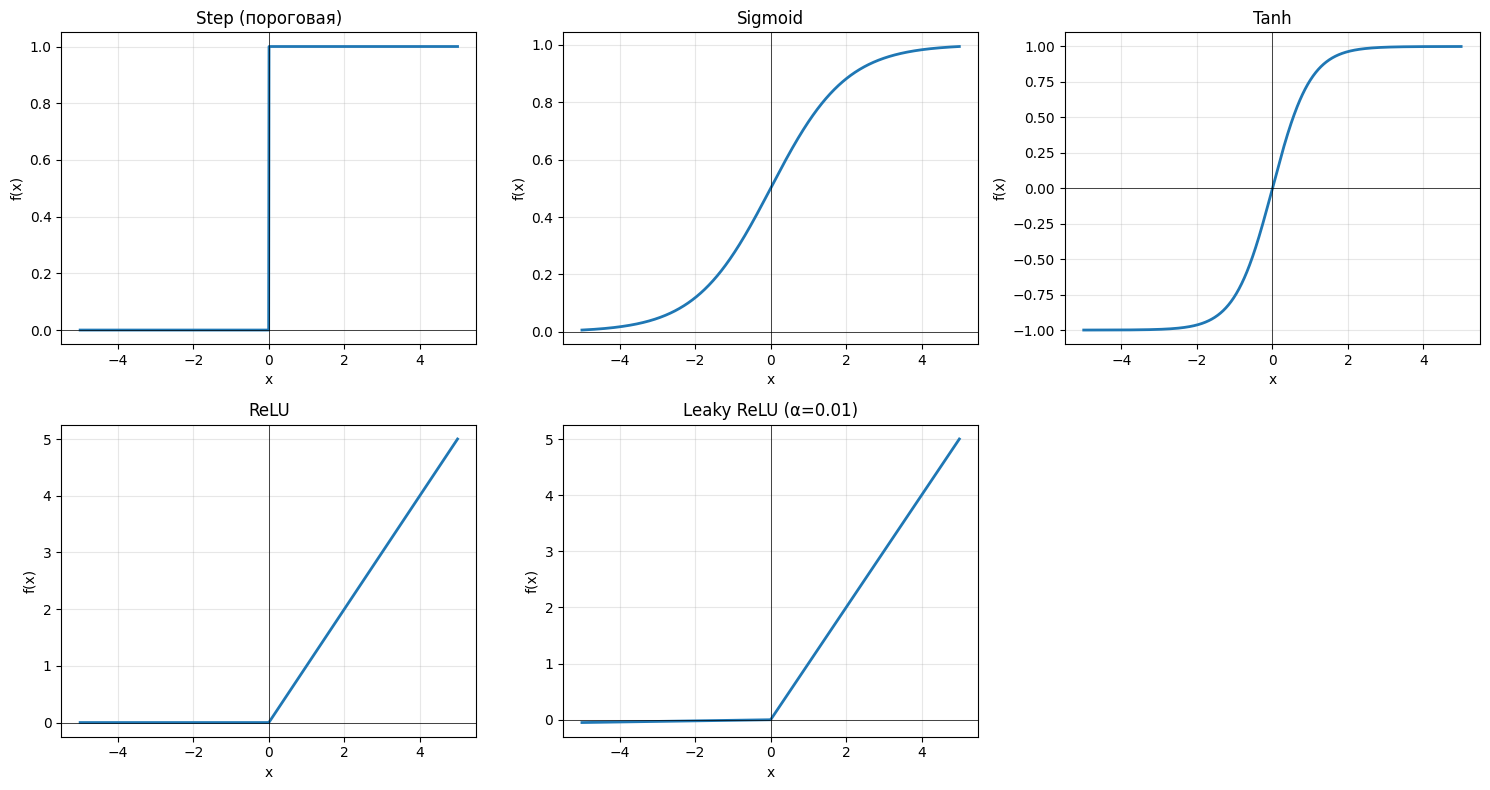

In [47]:
# -------------------------------------------------
# Визуализация всех функций
# -------------------------------------------------

x = np.linspace(-5, 5, 1000)

# Создаем фигуру с подграфиками
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()  # упрощаем индексацию
functions = [
    ("Step (пороговая)", ActivationFunctions.step(x)),
    ("Sigmoid", ActivationFunctions.sigmoid(x)),
    ("Tanh", ActivationFunctions.tanh(x)),
    ("ReLU", ActivationFunctions.relu(x)),
    ("Leaky ReLU (α=0.01)", ActivationFunctions.leaky_relu(x)),
]

for idx, (title, y) in enumerate(functions):
    axes[idx].plot(x, y, linewidth=2)
    axes[idx].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[idx].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_title(title, fontsize=12)
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('f(x)')


# Скрываем пустой 6-й подграфик
axes[5].axis('off')

plt.tight_layout()
plt.show()

In [48]:
# -------------------------------------------------
# Демонстрация на примере нейрона
# -------------------------------------------------

class NeuronWithActivation:
    """Нейрон с выбираемой функцией активации"""
    
    def __init__(self, weights, bias, activation='sigmoid'):
        self.weights = np.array(weights)
        self.bias = bias
        self.activation = activation
    
    def activate(self, x):
        if self.activation == 'step':
            return ActivationFunctions.step(x)
        elif self.activation == 'sigmoid':
            return ActivationFunctions.sigmoid(x)
        elif self.activation == 'tanh':
            return ActivationFunctions.tanh(x)
        elif self.activation == 'relu':
            return ActivationFunctions.relu(x)
        elif self.activation == 'leaky_relu':
            return ActivationFunctions.leaky_relu(x)
    
    def forward(self, inputs):
        z = np.dot(inputs, self.weights) + self.bias
        return self.activate(z)

# Проверяем на задаче "идти на улицу"
print("\n" + "="*60)
print("Как функция активации меняет решение нейрона")
print("="*60)

inputs = np.array([0, 1])  # холодно, дождь
weights = [0.5, -2]
bias = 0.5

for activation in ['step', 'sigmoid', 'tanh', 'relu', 'leaky_relu']:
    neuron = NeuronWithActivation(weights, bias, activation)
    output = neuron.forward(inputs)
    
    # Для step интерпретируем как 0/1
    if activation == 'step':
        decision = "❌ Дома" if output == 0 else "✅ Идём"
    else:
        # Для гладких функций смотрим на значение
        decision = f"Выход = {output:.3f} (вероятность/активация)"
    
    print(f"{activation:12} -> {decision}")


Как функция активации меняет решение нейрона
step         -> ❌ Дома
sigmoid      -> Выход = 0.182 (вероятность/активация)
tanh         -> Выход = -0.905 (вероятность/активация)
relu         -> Выход = 0.000 (вероятность/активация)
leaky_relu   -> Выход = -0.015 (вероятность/активация)


In [49]:
neuron = NeuronWithActivation(weights=[2, -3], bias=0.5, activation='sigmoid')

# Проверь для всех комбинаций [температура, дождь]
test_inputs = [[1,0], [1,1], [0,0], [0,1]]
for inp in test_inputs:
    out = neuron.forward(inp)
    print(f"inp={inp}, sigmoid output={out:.3f}")

inp=[1, 0], sigmoid output=0.924
inp=[1, 1], sigmoid output=0.378
inp=[0, 0], sigmoid output=0.622
inp=[0, 1], sigmoid output=0.076


In [50]:
# Найди производную сигмоиды при больших положительных и отрицательных z
def sigmoid_derivative(x):
    s = ActivationFunctions.sigmoid(x)
    return s * (1 - s)

# Проверь для z = -10, -5, 0, 5, 10
for z in [-10, -5, 0, 5, 10]:
    grad = sigmoid_derivative(z)
    print(f"z={z:3d}, производная={grad:.6f}")

z=-10, производная=0.000045
z= -5, производная=0.006648
z=  0, производная=0.250000
z=  5, производная=0.006648
z= 10, производная=0.000045


Проблема цепного правила (chain rule)
В глубокой сети с L слоями градиент первого слоя:

∂Loss/∂W₁ = (производная_активации_слоя_L) × ... × (производная_активации_слоя_1) × (производная_loss)
Если каждая сигмоида дает множитель 0.1-0.25, то для 10 слоев:

0.25¹⁰ ≈ 0.00000095  (почти ноль!)
Результат: Первые слои не учатся или учатся чрезвычайно медленно.

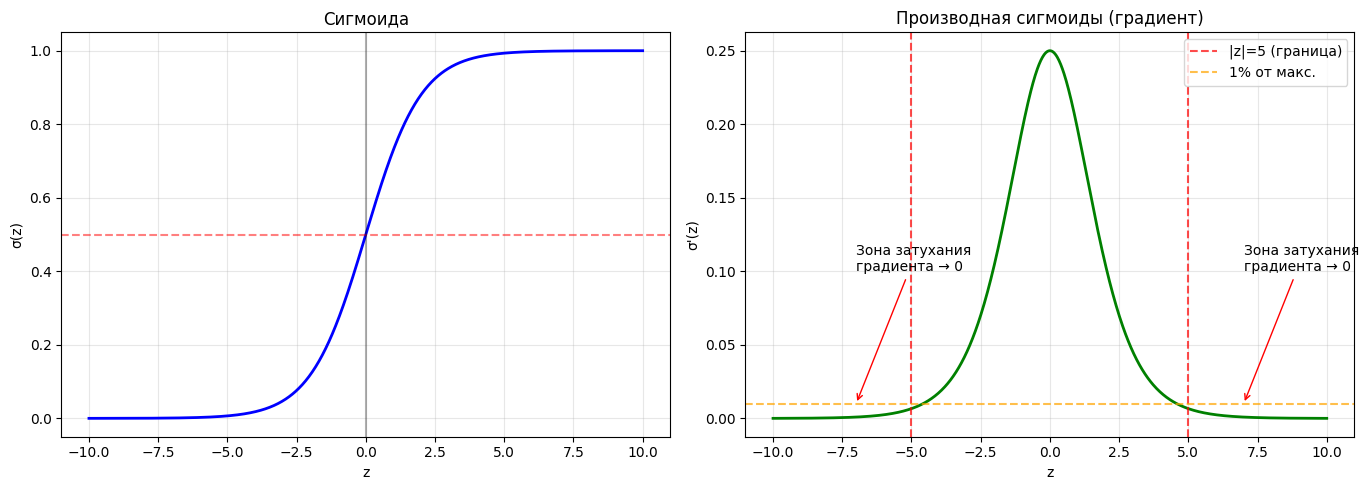

In [51]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# Строим график
x = np.linspace(-10, 10, 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Сигмоида
ax1.plot(x, sigmoid(x), 'b-', linewidth=2)
ax1.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
ax1.axvline(x=0, color='k', linestyle='-', alpha=0.3)
ax1.set_title('Сигмоида')
ax1.set_xlabel('z')
ax1.set_ylabel('σ(z)')
ax1.grid(True, alpha=0.3)

# Производная сигмоиды
ax2.plot(x, sigmoid_derivative(x), 'g-', linewidth=2)
ax2.axvline(x=5, color='r', linestyle='--', alpha=0.7, label='|z|=5 (граница)')
ax2.axvline(x=-5, color='r', linestyle='--', alpha=0.7)
ax2.axhline(y=0.01, color='orange', linestyle='--', alpha=0.7, label='1% от макс.')
ax2.set_title('Производная сигмоиды (градиент)')
ax2.set_xlabel('z')
ax2.set_ylabel("σ'(z)")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Добавляем аннотации
ax2.annotate('Зона затухания\nградиента → 0', xy=(7, 0.01), xytext=(7, 0.1),
             arrowprops=dict(arrowstyle='->', color='red'), fontsize=10)
ax2.annotate('Зона затухания\nградиента → 0', xy=(-7, 0.01), xytext=(-7, 0.1),
             arrowprops=dict(arrowstyle='->', color='red'), fontsize=10)

plt.tight_layout()
plt.show()


In [52]:
# Симуляция глубокой сети
print("\n" + "="*60)
print("Симуляция: умножение градиентов в глубокой сигмоидной сети")
print("="*60)

n_layers = [1, 2, 3, 5, 10, 20]
for layers in n_layers:
    # Худший случай: все z ≈ 0 (макс градиент 0.25)
    max_grad_product = 0.25 ** layers
    # Типичный случай: z ≈ 2-3 (градиент ~0.1)
    typical_grad_product = 0.1 ** layers
    
    print(f"\n{layers} слоёв:")
    print(f"  Макс градиент (z≈0):     {max_grad_product:.2e}")
    print(f"  Типичный градиент (z≈2): {typical_grad_product:.2e}")


Симуляция: умножение градиентов в глубокой сигмоидной сети

1 слоёв:
  Макс градиент (z≈0):     2.50e-01
  Типичный градиент (z≈2): 1.00e-01

2 слоёв:
  Макс градиент (z≈0):     6.25e-02
  Типичный градиент (z≈2): 1.00e-02

3 слоёв:
  Макс градиент (z≈0):     1.56e-02
  Типичный градиент (z≈2): 1.00e-03

5 слоёв:
  Макс градиент (z≈0):     9.77e-04
  Типичный градиент (z≈2): 1.00e-05

10 слоёв:
  Макс градиент (z≈0):     9.54e-07
  Типичный градиент (z≈2): 1.00e-10

20 слоёв:
  Макс градиент (z≈0):     9.09e-13
  Типичный градиент (z≈2): 1.00e-20


А как ReLU решает эту проблему?

In [53]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

# Сравним градиенты
print("\n" + "="*60)
print("Сравнение градиентов: Sigmoid vs ReLU")
print("="*60)

z_vals = [-10, -5, -1, 0, 1, 5, 10]
print(f"{'z':>5} | {'Sigmoid derivative':>18} | {'ReLU derivative':>15}")
print("-" * 45)

for z in z_vals:
    sig_grad = sigmoid_derivative(z)
    relu_grad = relu_derivative(z)
    print(f"{z:5d} | {sig_grad:.6f}            | {relu_grad}")


Сравнение градиентов: Sigmoid vs ReLU
    z | Sigmoid derivative | ReLU derivative
---------------------------------------------
  -10 | 0.000045            | 0
   -5 | 0.006648            | 0
   -1 | 0.196612            | 0
    0 | 0.250000            | 0
    1 | 0.196612            | 1
    5 | 0.006648            | 1
   10 | 0.000045            | 1


In [56]:
# Для ReLU в глубокой сети: если все активации > 0, производная = 1
# Тогда градиент перемножается как 1 * 1 * 1 * ... = 1 (нормально)

# А что, если использовать активацию, производная которой > 1? Например...

def bad_activation(x):
    return 2 * x  # производная = 2


# Для 50 слоев: 2^50 ≈ 1.12e15 (ОГРОМНЫЙ градиент!)
n_layers = [1, 2, 3, 5, 10, 20]
for layers in n_layers:
    typical_grad_product = 2 ** layers
    
    print(f"\n{layers} слоёв:")
    print(f"  Типичный градиент : {typical_grad_product:.2e}")



1 слоёв:
  Типичный градиент : 2.00e+00

2 слоёв:
  Типичный градиент : 4.00e+00

3 слоёв:
  Типичный градиент : 8.00e+00

5 слоёв:
  Типичный градиент : 3.20e+01

10 слоёв:
  Типичный градиент : 1.02e+03

20 слоёв:
  Типичный градиент : 1.05e+06


In [57]:
import numpy as np

# Симуляция взрыва градиента
def simulate_gradient_explosion(n_layers, grad_multiplier=2):
    """
    grad_multiplier = производная функции активации
    """
    initial_gradient = 1.0
    final_gradient = initial_gradient * (grad_multiplier ** n_layers)
    return final_gradient

print("\n" + "="*60)
print("ВЗРЫВ ГРАДИЕНТА: демонстрация проблемы")
print("="*60)

for layers in [5, 10, 20, 30, 50]:
    grad = simulate_gradient_explosion(layers, grad_multiplier=2)
    print(f"{layers:3d} слоёв: градиент = {grad:.2e}")
    
    # Что это значит для обновления весов?
    if grad > 1e6:
        print(f"         ⚠️ ГРАДИЕНТ ВЗОРВАЛСЯ! Обновление весов нестабильно")


ВЗРЫВ ГРАДИЕНТА: демонстрация проблемы
  5 слоёв: градиент = 3.20e+01
 10 слоёв: градиент = 1.02e+03
 20 слоёв: градиент = 1.05e+06
         ⚠️ ГРАДИЕНТ ВЗОРВАЛСЯ! Обновление весов нестабильно
 30 слоёв: градиент = 1.07e+09
         ⚠️ ГРАДИЕНТ ВЗОРВАЛСЯ! Обновление весов нестабильно
 50 слоёв: градиент = 1.13e+15
         ⚠️ ГРАДИЕНТ ВЗОРВАЛСЯ! Обновление весов нестабильно


In [58]:
# Демонстрация: нормальный vs взорванный градиент
learning_rate = 0.01
initial_weight = 1.0

print("\n" + "="*60)
print("Влияние взрыва градиента на обновление весов")
print("="*60)

# Нормальный градиент
normal_grad = 0.5
new_weight_normal = initial_weight - learning_rate * normal_grad
print(f"\nНормальный градиент ({normal_grad}):")
print(f"  w_old = {initial_weight}")
print(f"  w_new = {new_weight_normal:.4f}  (стабильно)")

# Взорванный градиент
exploded_grad = 1e9
new_weight_exploded = initial_weight - learning_rate * exploded_grad
print(f"\nВзорванный градиент ({exploded_grad:.0e}):")
print(f"  w_old = {initial_weight}")
print(f"  w_new = {new_weight_exploded:.0f}  (⚠️ ОГРОМНЫЙ СКАЧОК!)")


Влияние взрыва градиента на обновление весов

Нормальный градиент (0.5):
  w_old = 1.0
  w_new = 0.9950  (стабильно)

Взорванный градиент (1e+09):
  w_old = 1.0
  w_new = -9999999  (⚠️ ОГРОМНЫЙ СКАЧОК!)


### Слайд 10: Современные функции активации

In [59]:
import numpy as np
import matplotlib.pyplot as plt

class ModernActivations:
    """Современные функции активации"""
    
    @staticmethod
    def sigmoid(x):
        """Классическая сигмоида (для сравнения)"""
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    @staticmethod
    def relu(x):
        """Классический ReLU (для сравнения)"""
        return np.maximum(0, x)
    
    @staticmethod
    def elu(x, alpha=1.0):
        """
        Exponential Linear Unit
        Для x ≤ 0: alpha * (e^x - 1)
        Для x > 0: x
        """
        result = np.where(x > 0, x, alpha * (np.exp(x) - 1))
        return result
    
    @staticmethod
    def swish(x, beta=1.0):
        """
        Swish: x * sigmoid(beta * x)
        Автоматически гладкая, не затухает полностью
        """
        return x * ModernActivations.sigmoid(beta * x)
    
    @staticmethod
    def gelu(x):
        """
        GELU (Gaussian Error Linear Unit)
        x * Φ(x), где Φ — функция распределения стандартного нормального распределения
        Аппроксимация для скорости вычислений
        """
        # Точная формула: x * P(X <= x) где X ~ N(0,1)
        # Приближенная формула (быстрая):
        return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))
    
    @staticmethod
    def mish(x):
        """
        Mish: x * tanh(softplus(x))
        Softplus(x) = ln(1 + e^x)
        """
        softplus = np.log(1 + np.exp(x))
        return x * np.tanh(softplus)

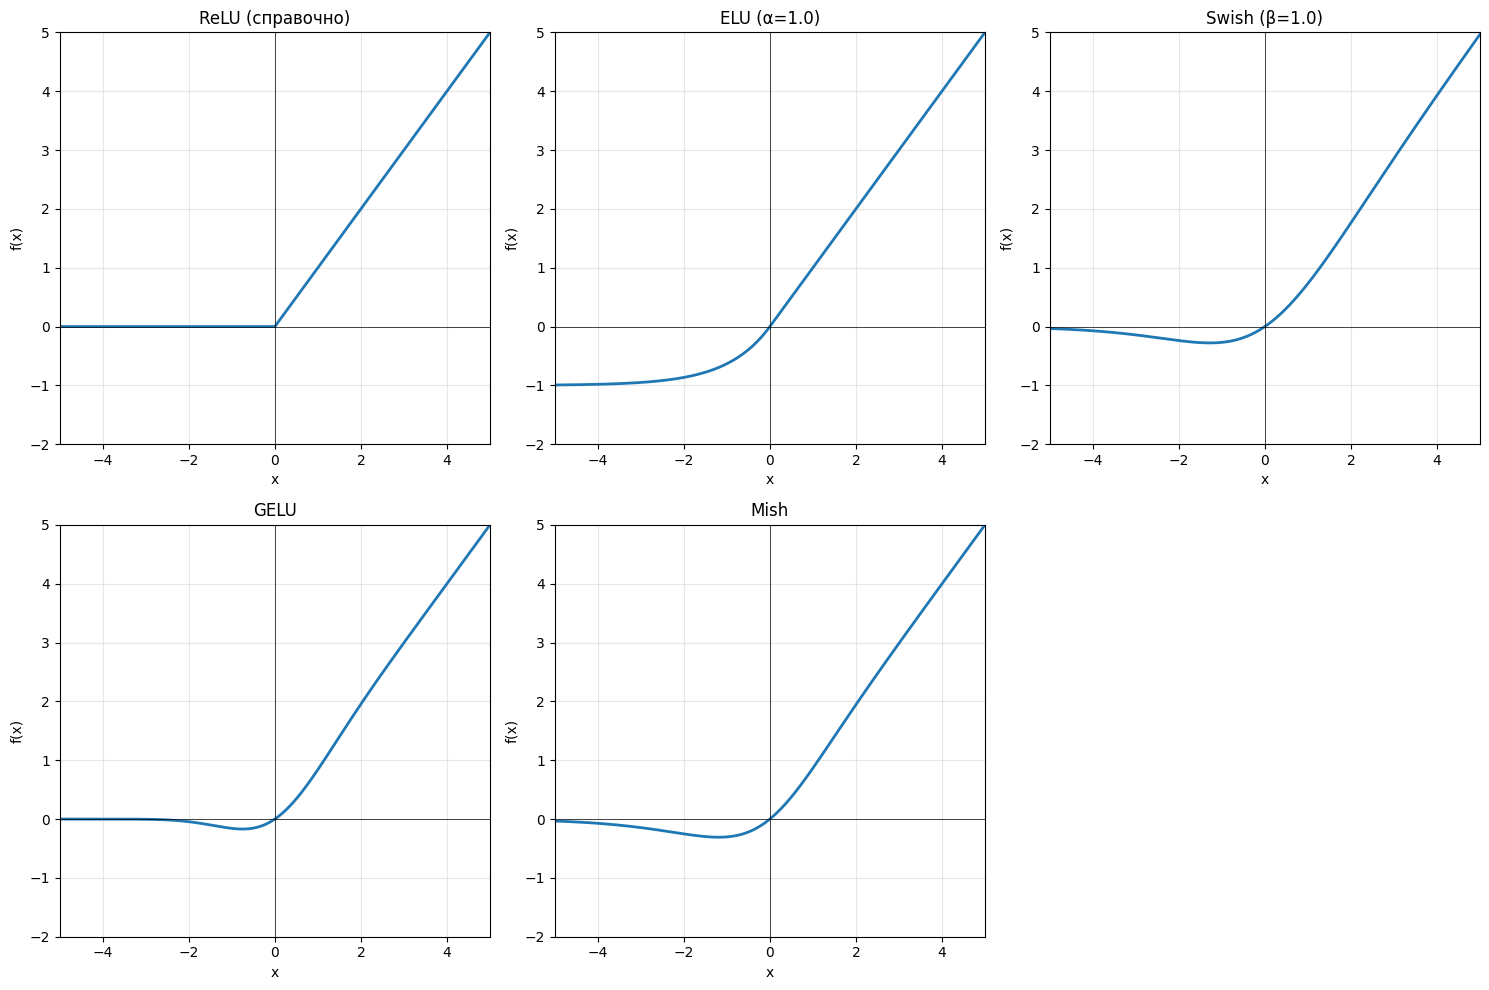

In [60]:

# -------------------------------------------------
# Визуализация всех современных функций
# -------------------------------------------------

x = np.linspace(-5, 5, 1000)

# Создаем фигуру
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

activations = [
    ("ReLU (справочно)", ModernActivations.relu(x)),
    ("ELU (α=1.0)", ModernActivations.elu(x)),
    ("Swish (β=1.0)", ModernActivations.swish(x)),
    ("GELU", ModernActivations.gelu(x)),
    ("Mish", ModernActivations.mish(x)),
]

for idx, (title, y) in enumerate(activations):
    axes[idx].plot(x, y, linewidth=2)
    axes[idx].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[idx].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_title(title, fontsize=12)
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('f(x)')
    axes[idx].set_xlim(-5, 5)
    axes[idx].set_ylim(-2, 5)

# Скрываем пустой 6-й подграфик
axes[5].axis('off')

plt.tight_layout()
plt.show()


In [62]:
# -------------------------------------------------
# Сравнение производных
# -------------------------------------------------

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

def elu_derivative(x, alpha=1.0):
    """Производная ELU"""
    return np.where(x > 0, 1, alpha * np.exp(x))

def swish_derivative(x, beta=1.0):
    """Производная Swish (упрощенная)"""
    s = ModernActivations.sigmoid(beta * x)
    return beta * s * (1 - s) * x + s

print("\n" + "="*70)
print("Сравнение значений и производных при x = -2, 0, 2")
print("="*70)

x_vals = [-2, 0, 2]

print(f"{'x':>3} | {'ReLU':^12} | {'ReLU':^12} | {'ELU':^12} | {'ELU':^12} | {'Swish':^12} | {'GELU':^12}")
print("-" * 80)

for x_val in x_vals:
    relu_val = ModernActivations.relu(x_val)
    relu_der = relu_derivative(x_val)
    elu_val = ModernActivations.elu(x_val)
    elu_der = elu_derivative(x_val)
    swish_val = ModernActivations.swish(x_val)
    gelu_val = ModernActivations.gelu(x_val)
    
    print(f"{x_val:3d} | {relu_val:12.4f} | {relu_der:12.4f} | {elu_val:12.4f} | {elu_der:12.4f} | {swish_val:12.4f} | {gelu_val:12.4f}")


Сравнение значений и производных при x = -2, 0, 2
  x |     ReLU     |     ReLU     |     ELU      |     ELU      |    Swish     |     GELU    
--------------------------------------------------------------------------------
 -2 |       0.0000 |       0.0000 |      -0.8647 |       0.1353 |      -0.2384 |      -0.0454
  0 |       0.0000 |       0.0000 |       0.0000 |       1.0000 |       0.0000 |       0.0000
  2 |       2.0000 |       1.0000 |       2.0000 |       1.0000 |       1.7616 |       1.9546


Эксперимент: проблема мертвых нейронов

In [68]:
# Симуляция мертвых нейронов в ReLU
print("\n" + "="*70)
print("Демонстрация: мертвые нейроны в ReLU")
print("="*70)

def simulate_dead_neurons():
    # Представим слой из 10 нейронов
    n_neurons = 10
    
    # Веса некоторых нейронов сместились так, 
    # что все их входы отрицательные
    neuron_inputs = np.random.randn(n_neurons, 100) * 2 - 10  # многие отрицательные
    
    # ReLU выходы
    relu_outputs = ModernActivations.relu(neuron_inputs)
    elu_outputs = ModernActivations.elu(neuron_inputs)
    
    # Считаем мертвые нейроны (все выходы = 0)
    dead_relu = np.sum(np.all(relu_outputs == 0, axis=1))
    dead_elu = np.sum(np.all(elu_outputs == 0, axis=1))
    
    print(f"Мертвых нейронов в ReLU: {dead_relu}/{n_neurons}")
    print(f"Мертвых нейронов в ELU:  {dead_elu}/{n_neurons}")
    print("\nВывод: ELU полностью устраняет проблему мертвых нейронов!")

simulate_dead_neurons()


Демонстрация: мертвые нейроны в ReLU
Мертвых нейронов в ReLU: 10/10
Мертвых нейронов в ELU:  0/10

Вывод: ELU полностью устраняет проблему мертвых нейронов!


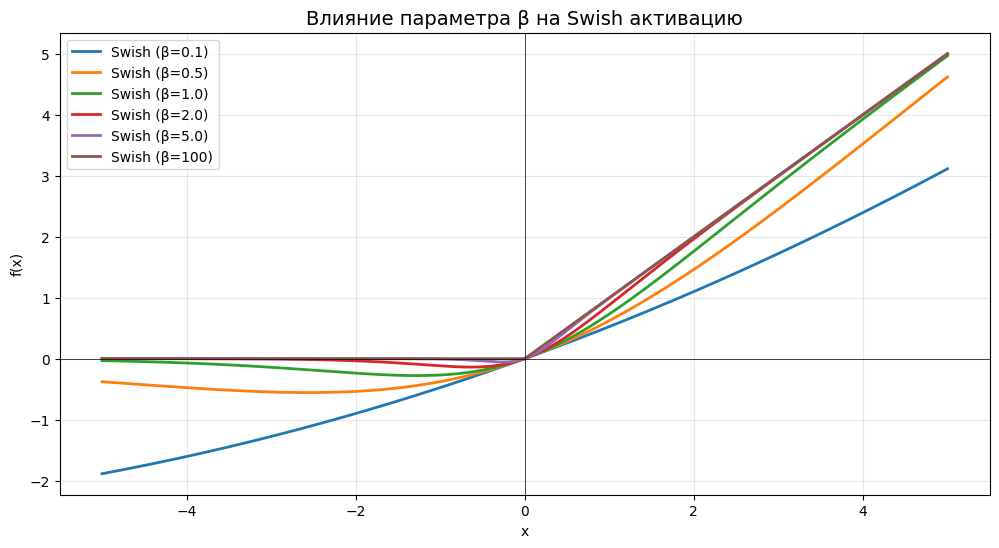

In [70]:
# Эксперимент: как β влияет на Swish
x = np.linspace(-5, 5, 1000)
betas = [0.1, 0.5, 1.0, 2.0, 5.0,100]

plt.figure(figsize=(12, 6))
for beta in betas:
    y = ModernActivations.swish(x, beta=beta)
    plt.plot(x, y, linewidth=2, label=f'Swish (β={beta})')

plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.title('Влияние параметра β на Swish активацию', fontsize=14)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()

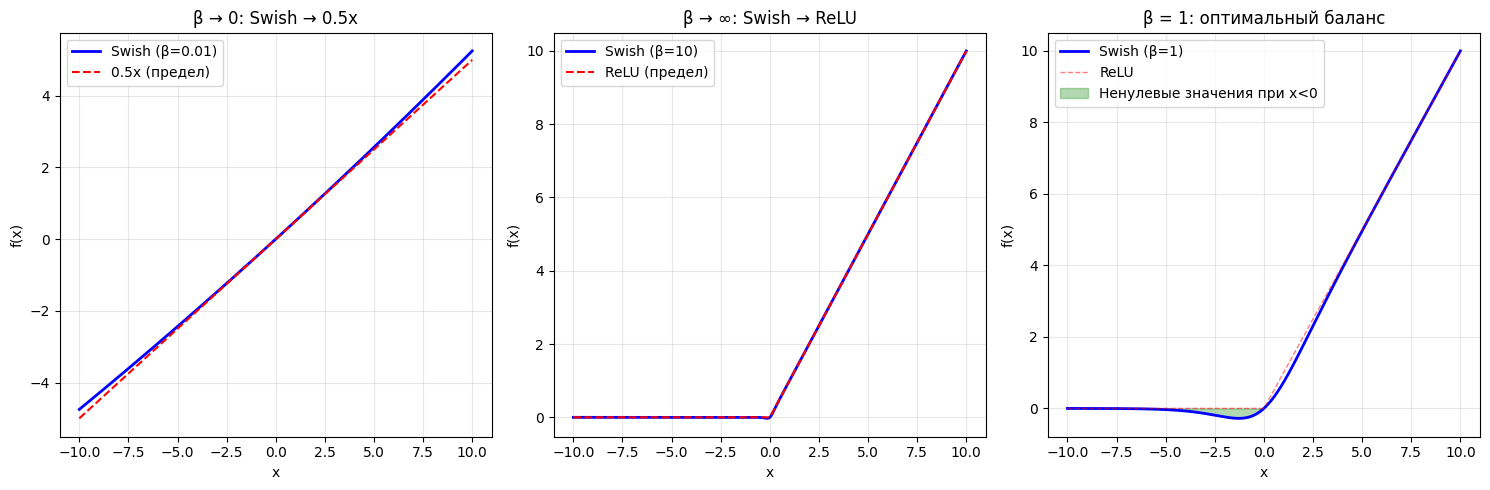

In [71]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def swish(x, beta=1.0):
    return x * sigmoid(beta * x)

x = np.linspace(-10, 10, 1000)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# График 1: β → 0
axes[0].plot(x, swish(x, beta=0.01), 'b-', linewidth=2, label='Swish (β=0.01)')
axes[0].plot(x, x * 0.5, 'r--', linewidth=1.5, label='0.5x (предел)')
axes[0].set_title('β → 0: Swish → 0.5x', fontsize=12)
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: β → ∞
axes[1].plot(x, swish(x, beta=10), 'b-', linewidth=2, label='Swish (β=10)')
axes[1].plot(x, np.maximum(0, x), 'r--', linewidth=1.5, label='ReLU (предел)')
axes[1].set_title('β → ∞: Swish → ReLU', fontsize=12)
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# График 3: β = 1 (почему выбран)
axes[2].plot(x, swish(x, beta=1), 'b-', linewidth=2, label='Swish (β=1)')
axes[2].plot(x, np.maximum(0, x), 'r--', linewidth=1, alpha=0.5, label='ReLU')
axes[2].fill_between(x[x<0], swish(x[x<0], beta=1), 0, alpha=0.3, color='green', label='Ненулевые значения при x<0')
axes[2].set_title('β = 1: оптимальный баланс', fontsize=12)
axes[2].set_xlabel('x')
axes[2].set_ylabel('f(x)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [72]:
def swish_derivative(x, beta=1.0):
    """Производная Swish"""
    s = sigmoid(beta * x)
    return beta * s * (1 - s) * x + s

print("\n" + "="*70)
print("Производная Swish при x = -2 (отрицательная зона)")
print("="*70)

x_neg = -2.0
betas = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

print(f"{'β':>5} | {'Swish(x)':>12} | {'Swish\'(x)':>14} | {'ReLU\'(x)':>14}")
print("-" * 52)

for beta in betas:
    val = swish(x_neg, beta)
    der = swish_derivative(x_neg, beta)
    relu_der = 0  # ReLU производная при x<0 = 0
    
    marker = "✅" if der > 0.01 else "⚠️"
    print(f"{beta:5.1f} | {val:12.4f} | {der:14.4f} {marker} | {relu_der:14}")


Производная Swish при x = -2 (отрицательная зона)
    β |     Swish(x) |      Swish'(x) |       ReLU'(x)
----------------------------------------------------
  0.1 |      -0.9003 |         0.4007 ✅ |              0
  0.5 |      -0.5379 |         0.0723 ✅ |              0
  1.0 |      -0.2384 |        -0.0908 ⚠️ |              0
  2.0 |      -0.0360 |        -0.0527 ⚠️ |              0
  5.0 |      -0.0001 |        -0.0004 ⚠️ |              0
 10.0 |      -0.0000 |        -0.0000 ⚠️ |              0


In [73]:
print("\n" + "="*70)
print("Сравнение функций активации на практике")
print("="*70)

comparison = {
    "Свойство": ["Мертвые нейроны", "Гладкость", "Вычислительная скорость", "Стандарт для", "Где побеждает"],
    "ReLU": ["Есть ⚠️", "Нет (в 0)", "Очень быстрая 🚀", "CV (ResNet, CNN)", "Большие сверточные сети"],
    "Swish": ["Нет ✅", "Да (∞)", "Быстрая", "Мобильные сети", "EfficientNet, MobileNet"],
    "GELU": ["Нет ✅", "Да (∞)", "Средняя", "Трансформеры 🏆", "GPT, BERT, ViT"],
}

# Печать таблицы
for i in range(len(comparison["Свойство"])):
    print(f"{comparison['Свойство'][i]:25} | {comparison['ReLU'][i]:25} | {comparison['Swish'][i]:25} | {comparison['GELU'][i]:25}")


Сравнение функций активации на практике
Мертвые нейроны           | Есть ⚠️                   | Нет ✅                     | Нет ✅                    
Гладкость                 | Нет (в 0)                 | Да (∞)                    | Да (∞)                   
Вычислительная скорость   | Очень быстрая 🚀           | Быстрая                   | Средняя                  
Стандарт для              | CV (ResNet, CNN)          | Мобильные сети            | Трансформеры 🏆           
Где побеждает             | Большие сверточные сети   | EfficientNet, MobileNet   | GPT, BERT, ViT           


## Слайды 11-12: Архитектура нейронной сети + Веса и смещения

In [78]:
import numpy as np
import matplotlib.pyplot as plt

class NeuralNetwork:
    """
    Простая полносвязная нейронная сеть (MLP)
    """
    def __init__(self, layer_sizes, activation='relu'):
        """
        layer_sizes: список [входной_размер, размер_слоя1, размер_слоя2, ..., выходной_размер]
        Например: [2, 4, 4, 1] — 2 входа, 2 скрытых слоя по 4 нейрона, 1 выход
        """
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.weights = []  # список матриц весов
        self.biases = []   # список векторов смещений
        self.activations = []  # для хранения промежуточных результатов (forward)
        
        # Инициализация Xavier/Glorot
        for i in range(len(layer_sizes) - 1):
            # Веса: [размер_слоя_i, размер_слоя_{i+1}]
            w = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * np.sqrt(2 / (layer_sizes[i] + layer_sizes[i+1]))
            b = np.zeros((1, layer_sizes[i+1]))
            self.weights.append(w)
            self.biases.append(b)
    
    def activate(self, x, alpha=0.01):
        if self.activation == 'relu':
            return np.maximum(0, x)
        elif self.activation == 'leaky_relu':
            return np.where(x >= 0, x, alpha * x)
        elif self.activation == 'sigmoid':
            return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
        return x
    
    def forward(self, X):
        """
        Прямой проход (forward pass)
        X: входные данные (n_samples, n_features)
        """
        self.activations = [X]  # сохраняем входной слой
        
        current = X
        for w, b in zip(self.weights, self.biases):
            # z = W * a_prev + b
            z = np.dot(current, w) + b
            # a = f(z)
            current = self.activate(z)
            self.activations.append(current)
        
        return current
    
    def get_parameters_count(self):
        """Считает количество обучаемых параметров"""
        total = 0
        for i, (w, b) in enumerate(zip(self.weights, self.biases)):
            n_weights = w.shape[0] * w.shape[1]
            n_biases = b.shape[1]
            total += n_weights + n_biases
            print(f"Слой {i+1}: {w.shape[1]} нейронов | Веса: {n_weights} | Смещения: {n_biases} | Итого: {n_weights + n_biases}")
        print(f"-" * 40)
        print(f"Всего параметров: {total}")
        return total


In [79]:
# -------------------------------------------------
# Создаем сеть для задачи "идти на улицу"
# -------------------------------------------------

print("=" * 60)
print("СОЗДАНИЕ НЕЙРОННОЙ СЕТИ")
print("=" * 60)

# Архитектура: 2 входа → 3 нейрона → 3 нейрона → 1 выход
network = NeuralNetwork(layer_sizes=[2, 3, 3, 1], activation='leaky_relu')

print("\nАрхитектура сети:")
print("  Входной слой: 2 нейрона (температура, дождь)")
print("  Скрытый слой 1: 3 нейрона")
print("  Скрытый слой 2: 3 нейрона")
print("  Выходной слой: 1 нейрон (идти/не идти)")
print("\nОбучаемые параметры:")
network.get_parameters_count()

# -------------------------------------------------
# Демонстрация работы сети
# -------------------------------------------------

print("\n" + "=" * 60)
print("ПРЯМОЙ ПРОХОД (FORWARD PASS)")
print("=" * 60)

# Тестовые примеры
test_inputs = np.array([
    [1, 0],  # тепло, без дождя
    [1, 1],  # тепло, дождь
    [0, 0],  # холодно, без дождя
    [0, 1],  # холодно, дождь
])

# Запускаем прямой проход
outputs = network.forward(test_inputs)

print("Результаты (сетью управляют случайные веса):")
for i, (inputs, out) in enumerate(zip(test_inputs, outputs)):
    decision = "Идём" if out >= 0.5 else "Дома"
    print(f"  {['холодно', 'тепло'][inputs[0]]}, {['без дождя', 'дождь'][inputs[1]]:10} → {out[0]:.3f} → {decision}")

print("\n⚠️ Случайные веса дают случайные ответы. После обучения сеть научится правильно решать!")

СОЗДАНИЕ НЕЙРОННОЙ СЕТИ

Архитектура сети:
  Входной слой: 2 нейрона (температура, дождь)
  Скрытый слой 1: 3 нейрона
  Скрытый слой 2: 3 нейрона
  Выходной слой: 1 нейрон (идти/не идти)

Обучаемые параметры:
Слой 1: 3 нейронов | Веса: 6 | Смещения: 3 | Итого: 9
Слой 2: 3 нейронов | Веса: 9 | Смещения: 3 | Итого: 12
Слой 3: 1 нейронов | Веса: 3 | Смещения: 1 | Итого: 4
----------------------------------------
Всего параметров: 25

ПРЯМОЙ ПРОХОД (FORWARD PASS)
Результаты (сетью управляют случайные веса):
  тепло, без дождя  → 0.036 → Дома
  тепло, дождь      → 0.013 → Дома
  холодно, без дождя  → 0.000 → Дома
  холодно, дождь      → 0.004 → Дома

⚠️ Случайные веса дают случайные ответы. После обучения сеть научится правильно решать!


Ключевые моменты для понимания
Почему веса случайные?
Если все веса одинаковые → все нейроны будут учиться одинаково

Случайность "ломает симметрию"

Почему смещения нулевые?
Смещения могут быть нулевыми при старте, они быстро подстроятся

В отличие от весов, нулевые смещения не создают симметрию

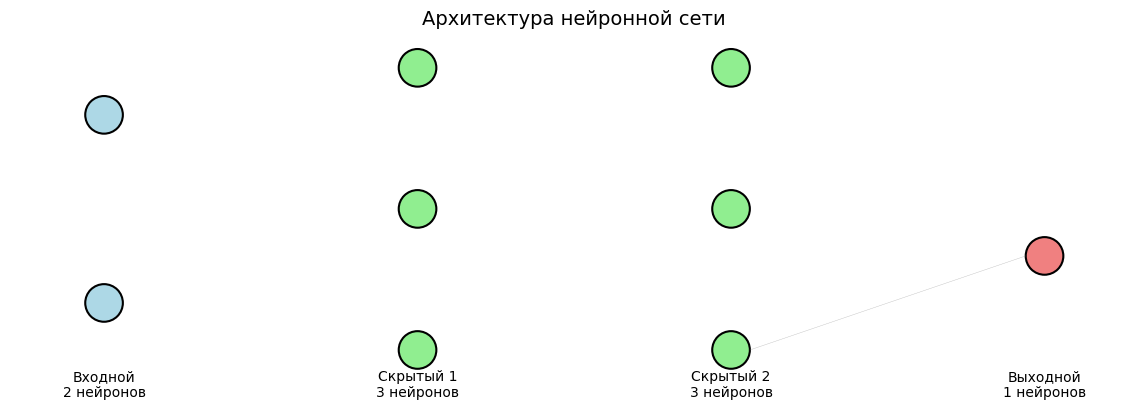

In [80]:
def visualize_architecture(layer_sizes):
    """
    Простая визуализация структуры сети
    """
    fig, ax = plt.subplots(figsize=(12, 4))
    
    # Позиции слоев по x
    x_positions = np.linspace(0, 10, len(layer_sizes))
    
    # Максимальное количество нейронов в слое (для масштабирования)
    max_neurons = max(layer_sizes)
    
    colors = ['lightblue', 'lightgreen', 'lightgreen', 'lightcoral']
    
    for layer_idx, (x, n_neurons) in enumerate(zip(x_positions, layer_sizes)):
        # Позиции нейронов по y
        y_positions = np.linspace(-n_neurons/2, n_neurons/2, n_neurons)
        
        # Рисуем нейроны
        for y in y_positions:
            circle = plt.Circle((x, y), 0.2, color=colors[layer_idx] if layer_idx < len(colors) else 'lightgray', 
                                ec='black', linewidth=1.5)
            ax.add_patch(circle)
        
        # Подпись слоя
        layer_names = ['Входной', 'Скрытый 1', 'Скрытый 2', 'Выходной']
        ax.text(x, -max_neurons/2 - 0.5, f"{layer_names[layer_idx]}\n{n_neurons} нейронов", 
                ha='center', fontsize=10)
        
        # Соединяем со следующим слоем
        if layer_idx < len(layer_sizes) - 1:
            next_x = x_positions[layer_idx + 1]
            next_n = layer_sizes[layer_idx + 1]
            next_y = np.linspace(-next_n/2, next_n/2, next_n)
            
            # Рисуем несколько случайных соединений (не все, чтобы не загромождать)
            for y in y_positions:
                for next_y_val in next_y:
                    if np.random.random() < 0.15:  # 15% соединений
                        ax.plot([x + 0.2, next_x - 0.2], [y, next_y_val], 
                               'gray', linewidth=0.3, alpha=0.5)
    
    ax.set_xlim(-1, 11)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title("Архитектура нейронной сети", fontsize=14)
    plt.tight_layout()
    plt.show()

# Визуализируем нашу сеть
visualize_architecture([2, 3, 3, 1])

In [81]:
print("\n" + "=" * 60)
print("МАТЕМАТИКА ПОЛНОСВЯЗНОГО СЛОЯ")
print("=" * 60)

# Демонстрация с маленькими числами
n_inputs = 3
n_neurons = 4

W = np.array([[0.1, 0.2, 0.3, 0.4],
              [0.5, 0.6, 0.7, 0.8],
              [0.9, 1.0, 1.1, 1.2]])
b = np.array([0.01, 0.02, 0.03, 0.04])

print(f"Матрица весов W: {W.shape}")
print(f"Строка i = входной нейрон i, колонка j = выходной нейрон j")
print(f"Вектор смещений b: {b.shape}\n")

# Входной вектор
a_prev = np.array([0.5, 0.3, 0.2])
print(f"Входной вектор a_prev: {a_prev} (3 нейрона входного слоя)")

# Вычисление
z = np.dot(a_prev, W) + b
print(f"\nz = a_prev * W + b = {z}")
print(f"Это взвешенная сумма для каждого из {n_neurons} нейронов")

# После функции активации
a = np.maximum(0, z)  # ReLU
print(f"a = ReLU(z) = {a} (выходы нейронов)")


МАТЕМАТИКА ПОЛНОСВЯЗНОГО СЛОЯ
Матрица весов W: (3, 4)
Строка i = входной нейрон i, колонка j = выходной нейрон j
Вектор смещений b: (4,)

Входной вектор a_prev: [0.5 0.3 0.2] (3 нейрона входного слоя)

z = a_prev * W + b = [0.39 0.5  0.61 0.72]
Это взвешенная сумма для каждого из 4 нейронов
a = ReLU(z) = [0.39 0.5  0.61 0.72] (выходы нейронов)


In [82]:
print("\n" + "=" * 60)
print("ЗАЧЕМ НУЖНЫ ГЛУБОКИЕ СЕТИ?")
print("=" * 60)

def demonstrate_need_for_depth():
    """
    Один слой может решать только линейные задачи (XOR не решает)
    Два слоя могут решать XOR и любые логические функции
    """
    
    print("\nЗадача XOR:")
    print("┌─────────┬─────────┬─────┐")
    print("│   x1    │   x2    │ x1⊕x2│")
    print("├─────────┼─────────┼─────┤")
    print("│    0    │    0    │  0  │")
    print("│    0    │    1    │  1  │")
    print("│    1    │    0    │  1  │")
    print("│    1    │    1    │  0  │")
    print("└─────────┴─────────┴─────┘")
    
    print("\nПочему один нейрон не может решить XOR?")
    print("  - Один нейрон задает линейную границу (прямую)")
    print("  - Данные XOR не разделяются одной прямой")
    print("  - Нужна НЕЛИНЕЙНАЯ граница → минимум 2 слоя!")

demonstrate_need_for_depth()


ЗАЧЕМ НУЖНЫ ГЛУБОКИЕ СЕТИ?

Задача XOR:
┌─────────┬─────────┬─────┐
│   x1    │   x2    │ x1⊕x2│
├─────────┼─────────┼─────┤
│    0    │    0    │  0  │
│    0    │    1    │  1  │
│    1    │    0    │  1  │
│    1    │    1    │  0  │
└─────────┴─────────┴─────┘

Почему один нейрон не может решить XOR?
  - Один нейрон задает линейную границу (прямую)
  - Данные XOR не разделяются одной прямой
  - Нужна НЕЛИНЕЙНАЯ граница → минимум 2 слоя!


XOR 


In [83]:
# XOR задача: входы [0,0] → 0, [0,1] → 1, [1,0] → 1, [1,1] → 0
xor_network = NeuralNetwork(layer_sizes=[2, 4, 1], activation='relu')

# Данные для XOR
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([[0], [1], [1], [0]])

# Прямой проход со случайными весами
outputs = xor_network.forward(X_xor)

print("\nXOR решение со случайными весами:")
for i, (x, out, target) in enumerate(zip(X_xor, outputs, y_xor)):
    print(f"  {x} → {out[0]:.3f} (цель: {target[0]})")

# Вопрос: почему один слой (перцептрон) не может решить XOR?
# Ответ: потому что XOR не является линейно разделимым


XOR решение со случайными весами:
  [0 0] → 0.000 (цель: 0)
  [0 1] → 0.000 (цель: 1)
  [1 0] → 0.704 (цель: 1)
  [1 1] → 0.679 (цель: 0)


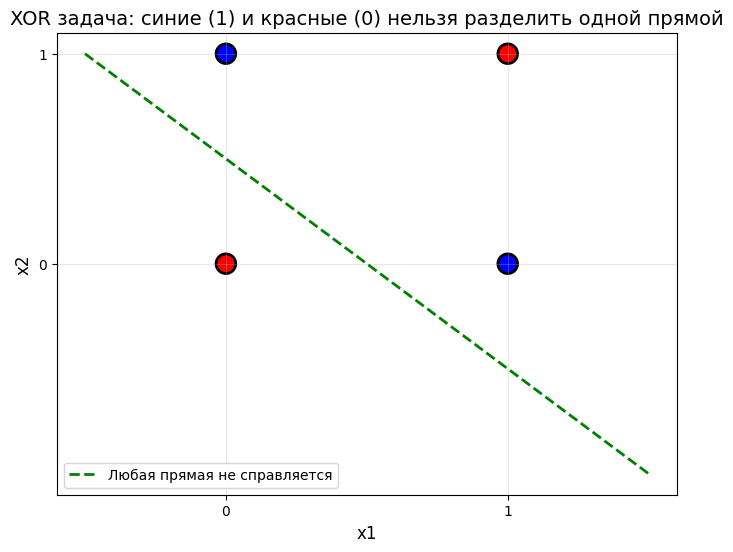

In [84]:
import numpy as np
import matplotlib.pyplot as plt

# Данные XOR
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])  # цели

# Визуализация
plt.figure(figsize=(8, 6))
colors = ['red' if y == 0 else 'blue' for y in y_xor]
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=colors, s=200, edgecolors='black', linewidth=2)
plt.xlabel('x1', fontsize=12)
plt.ylabel('x2', fontsize=12)
plt.title('XOR задача: синие (1) и красные (0) нельзя разделить одной прямой', fontsize=14)
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.grid(True, alpha=0.3)

# Попробуем провести прямую (безуспешно)
x_line = np.linspace(-0.5, 1.5, 100)
# Любая прямая оставит по одному красному и синему с каждой стороны
plt.plot(x_line, -x_line + 0.5, 'g--', linewidth=2, label='Любая прямая не справляется')
plt.legend()
plt.show()

In [86]:
import numpy as np

class XORNeuralNetwork:
    """
    Специально спроектированная сеть для XOR
    Архитектура: 2 входа → 2 нейрона скрытого слоя → 1 выход
    """
    def __init__(self):
        # Инициализируем веса маленькими случайными числами
        # Скрытый слой: 2 входа × 2 нейрона
        self.W1 = np.random.randn(2,2) * 0.5
        # Смещения для скрытого слоя
        self.b1 = np.random.randn(2) * 0.1
        # Выходной слой: 2 входа × 1 нейрон
        self.W2 = np.random.randn(2, 1) * 0.5
        # Смещение для выходного слоя
        self.b2 = np.random.randn(1) * 0.1

    def sigmoid(self,x):
        """Сигмоида для скрытого слоя"""
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    def sigmoid_derivative(self, x):
        """Производная сигмоиды"""
        s = self.sigmoid(x)
        return s * (1 - s)
    
    def forward(self,X):
        """
        Прямой проход
        X: (n_samples, 2)
        """
        # Скрытый слой
        self.z1 = np.dot(X,self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)

        # Выходной слой
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)

        return self.a2
    
    def compute_loss(self,y_pred,y_true):
        """Бинарная кросс-энтропия"""
        # Добавляем эпсилон для числовой стабильности
        eps = 1e-8
        y_pred = np.clip(y_pred, eps, 1 - eps)
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        return loss
    
    def train_step(self,X,y,learning_rate=0.5):
        """
        Один шаг обучения (обратное распространение)
        """
        n_samples = X.shape[0]

        # Forward pass (уже сделано в forward, но нам нужны промежуточные значения)
        output = self.forward(X)
        # Backward pass
        # Выходной слой
        d_loss_a2 = (output - y.reshape(-1, 1)) / n_samples
        d_a2_z2 = self.sigmoid_derivative(self.z2)
        d_z2_W2 = self.a1.T
        d_z2_b2 = np.ones(n_samples)
        
        # Градиенты для выходного слоя
        d_loss_W2 = np.dot(d_z2_W2, d_loss_a2 * d_a2_z2)
        d_loss_b2 = np.sum(d_loss_a2 * d_a2_z2, axis=0)
        
        # Ошибка для скрытого слоя
        d_loss_a1 = np.dot(d_loss_a2 * d_a2_z2, self.W2.T)
        d_a1_z1 = self.sigmoid_derivative(self.z1)
        d_z1_W1 = X.T
        d_z1_b1 = np.ones(n_samples)
        
        # Градиенты для скрытого слоя
        d_loss_W1 = np.dot(d_z1_W1, d_loss_a1 * d_a1_z1)
        d_loss_b1 = np.sum(d_loss_a1 * d_a1_z1, axis=0)
        
        # Обновление весов
        self.W2 -= learning_rate * d_loss_W2
        self.b2 -= learning_rate * d_loss_b2
        self.W1 -= learning_rate * d_loss_W1
        self.b1 -= learning_rate * d_loss_b1
        
        return self.compute_loss(output, y.reshape(-1, 1))
    
    def predict(self, X):
        """Бинарное предсказание (0 или 1)"""
        output = self.forward(X)
        return (output >= 0.5).astype(int).flatten()

In [87]:
# -------------------------------------------------
# Обучаем сеть
# -------------------------------------------------

print("=" * 60)
print("ОБУЧЕНИЕ НЕЙРОННОЙ СЕТИ ДЛЯ XOR")
print("=" * 60)

# Данные
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])

# Создаем сеть
model = XORNeuralNetwork()

print("\nДО ОБУЧЕНИЯ:")
print("-" * 40)
for i, (x, target) in enumerate(zip(X, y)):
    pred = model.predict(x.reshape(1, -1))
    print(f"Вход: {x} → Предсказание: {pred[0]} (цель: {target})")

# Обучение
print("\n" + "=" * 60)
print("ПРОЦЕСС ОБУЧЕНИЯ")
print("=" * 60)

epochs = 2000
loss_history = []

for epoch in range(epochs):
    loss = model.train_step(X, y, learning_rate=0.5)
    loss_history.append(loss)
    
    if epoch % 200 == 0:
        print(f"Эпоха {epoch:4d}: Loss = {loss:.6f}")

# Результаты
print("\n" + "=" * 60)
print("ПОСЛЕ ОБУЧЕНИЯ")
print("=" * 60)

print("\nПредсказания:")
for i, (x, target) in enumerate(zip(X, y)):
    pred = model.predict(x.reshape(1, -1))
    status = "✅" if pred[0] == target else "❌"
    print(f"{status} Вход: {x} → Предсказание: {pred[0]} (цель: {target})")

# Интроспекция: смотрим веса
print("\n" + "=" * 60)
print("ВНУТРЕННЕЕ УСТРОЙСТВО СЕТИ")
print("=" * 60)
print(f"Веса скрытого слоя W1:\n{model.W1}")
print(f"Смещения скрытого слоя b1: {model.b1}")
print(f"\nВеса выходного слоя W2:\n{model.W2}")
print(f"Смещение выходного слоя b2: {model.b2}")

ОБУЧЕНИЕ НЕЙРОННОЙ СЕТИ ДЛЯ XOR

ДО ОБУЧЕНИЯ:
----------------------------------------
Вход: [0 0] → Предсказание: 1 (цель: 0)
Вход: [0 1] → Предсказание: 1 (цель: 1)
Вход: [1 0] → Предсказание: 1 (цель: 1)
Вход: [1 1] → Предсказание: 1 (цель: 0)

ПРОЦЕСС ОБУЧЕНИЯ
Эпоха    0: Loss = 0.694183
Эпоха  200: Loss = 0.693128
Эпоха  400: Loss = 0.693125
Эпоха  600: Loss = 0.693121
Эпоха  800: Loss = 0.693117
Эпоха 1000: Loss = 0.693113
Эпоха 1200: Loss = 0.693108
Эпоха 1400: Loss = 0.693102
Эпоха 1600: Loss = 0.693096
Эпоха 1800: Loss = 0.693089

ПОСЛЕ ОБУЧЕНИЯ

Предсказания:
✅ Вход: [0 0] → Предсказание: 0 (цель: 0)
❌ Вход: [0 1] → Предсказание: 0 (цель: 1)
✅ Вход: [1 0] → Предсказание: 1 (цель: 1)
❌ Вход: [1 1] → Предсказание: 1 (цель: 0)

ВНУТРЕННЕЕ УСТРОЙСТВО СЕТИ
Веса скрытого слоя W1:
[[ 0.1004568  -0.22763017]
 [-0.42770724 -0.21641562]]
Смещения скрытого слоя b1: [-0.03058485 -0.03727917]

Веса выходного слоя W2:
[[ 0.26549303]
 [-0.27279453]]
Смещение выходного слоя b2: [-0.00133127]

In [3]:
def neuron(x1,x2,w1,w2,b):
    """
    Один искусственный нейрон с пороговой функцией активации
    
    Параметры:
    x1, x2 - входные сигналы
    w1, w2 - веса
    b - смещение (bias)
    
    Возвращает:
    1 или 0
    """
    z = x1*w1 + x2*w2 + b
    return 1 if z>=0 else 0

In [90]:
# Примеры для проверки
print("=== ТЕСТИРОВАНИЕ НЕЙРОНА ===")

# Тест 1: ИЛИ (OR)
# При x1=1 или x2=1 должен быть 1
print(f"OR: x1=0, x2=0 → {neuron(0, 0, 1, 1, -0.5)}")  # должно быть 0
print(f"OR: x1=0, x2=1 → {neuron(0, 1, 1, 1, -0.5)}")  # должно быть 1
print(f"OR: x1=1, x2=0 → {neuron(1, 0, 1, 1, -0.5)}")  # должно быть 1
print(f"OR: x1=1, x2=1 → {neuron(1, 1, 1, 1, -0.5)}")  # должно быть 1

# Тест 2: И (AND)
# Только когда оба 1 → выход 1
print(f"\nAND: x1=0, x2=0 → {neuron(0, 0, 1, 1, -1.5)}")  # должно быть 0
print(f"AND: x1=0, x2=1 → {neuron(0, 1, 1, 1, -1.5)}")  # должно быть 0
print(f"AND: x1=1, x2=0 → {neuron(1, 0, 1, 1, -1.5)}")  # должно быть 0
print(f"AND: x1=1, x2=1 → {neuron(1, 1, 1, 1, -1.5)}")  # должно быть 1

=== ТЕСТИРОВАНИЕ НЕЙРОНА ===
OR: x1=0, x2=0 → 0
OR: x1=0, x2=1 → 1
OR: x1=1, x2=0 → 1
OR: x1=1, x2=1 → 1

AND: x1=0, x2=0 → 0
AND: x1=0, x2=1 → 0
AND: x1=1, x2=0 → 0
AND: x1=1, x2=1 → 1


1. Как bias влияет на порог?
    b > 0 → нейрон легче активируется (чаще 1)
    b < 0 → нейрон труднее активируется (чаще 0)
    b = 0 → активация только когда w1*x1 + w2*x2 >= 0
2. Почему для AND bias = -1.5 (более отрицательный)?
"по задаче больше шанс получения 0"

Верно! Давай проверим математически:

In [ ]:
def neuron_general(inputs, weights, bias, activation='step',alpha = 0.01):
    # Шаг 1: проверка, что длины совпадают
    if len(inputs) != len(weights):
        raise ValueError("Количество входов должно равняться количеству весов")
    
    z = np.dot(inputs,weights) + bias

    
    if activation == 'step':
        return 1 if z>=0 else 0
    elif activation == 'sigmoid':
        return 1/(1+np.exp(-z))
    elif activation == 'relu':
        return max(0,z)
    elif activation == 'leaky_relu':
        return z if z>=0 else alpha*z
    elif activation == 'linear':
        return z
    else:
        raise ValueError(f"Неизвестная активация: {activation}")
    

In [94]:
# Проверка
print("\n=== ТЕСТИРОВАНИЕ ОБОБЩЕННОГО НЕЙРОНА ===")

# AND с разными активациями
inputs = [1, 1]
weights = [1, 1]
bias = -1.5

print(f"AND(1,1) с step:     {neuron_general(inputs, weights, bias, 'step')}")
print(f"AND(1,1) с sigmoid:  {neuron_general(inputs, weights, bias, 'sigmoid'):.4f}")
print(f"AND(1,1) с relu:     {neuron_general(inputs, weights, bias, 'relu')}")
print(f"AND(1,1) с leaky_relu: {neuron_general(inputs, weights, bias, 'leaky_relu'):.4f}")


=== ТЕСТИРОВАНИЕ ОБОБЩЕННОГО НЕЙРОНА ===
AND(1,1) с step:     1
AND(1,1) с sigmoid:  0.6225
AND(1,1) с relu:     0.5
AND(1,1) с leaky_relu: 0.5000


In [95]:
neuron_general([0, 0, 1], [0.5, -1, 2], 0, 'sigmoid')

np.float64(0.8807970779778823)

In [98]:
import numpy as np
def compute_loss(y_pred, y_true, loss_type='mse', eps=1e-8):
    if loss_type == 'mse':
        return (y_pred - y_true)**2
    elif loss_type == 'mae':
        return abs(y_pred - y_true)
    elif loss_type=='binary_cross_entropy':
        # Обрезаем y_pred в диапазон [eps, 1-eps]
        y_pred_clipped = np.clip(y_pred, eps, 1 - eps)
        return -(y_true * np.log(y_pred_clipped) + (1 - y_true) * np.log(1 - y_pred_clipped))
    else:
        raise ValueError(f"Неизвестная функция потерь: {loss_type}")

In [97]:
# Проверка
print("=== ФУНКЦИИ ПОТЕРЬ ===")

# MSE: (0.9 - 1)² = 0.01
print(f"MSE: {compute_loss(0.9, 1, 'mse')}")  # 0.01

# MAE: |0.9 - 1| = 0.1
print(f"MAE: {compute_loss(0.9, 1, 'mae')}")  # 0.1

# BCE: -[1*log(0.9) + 0*log(0.1)] = -log(0.9) = 0.1053
print(f"BCE: {compute_loss(0.9, 1, 'binary_cross_entropy'):.4f}")  # 0.1053

=== ФУНКЦИИ ПОТЕРЬ ===
MSE: 0.009999999999999995
MAE: 0.09999999999999998
BCE: 0.1054


In [ ]:
# Проверка с опасными значениями
print("=== ТЕСТ НА УСТОЙЧИВОСТЬ ===")

# При y_pred = 0 (хотя сигмоида почти никогда не дает ровно 0)
print(f"BCE при y_pred=0, y_true=1: {compute_loss(0, 1, 'binary_cross_entropy')}")
# Без clipping: -inf, с clipping: -log(1e-8) ≈ 18.42

# При y_pred = 1
print(f"BCE при y_pred=1, y_true=1: {compute_loss(1, 1, 'binary_cross_entropy')}")
# Без clipping: -log(1) - ... = 0, с clipping: небольшая погрешность

# Нормальный случай
print(f"BCE при y_pred=0.9, y_true=1: {compute_loss(0.9, 1, 'binary_cross_entropy'):.4f}")

=== ТЕСТ НА УСТОЙЧИВОСТЬ ===
BCE при y_pred=0, y_true=1: 18.420680743952367
BCE при y_pred=1, y_true=1: 1.0000000100247594e-08
BCE при y_pred=0.9, y_true=1: 0.1054


Как понять, в какую сторону менять вес w?
Идея: Если ошибка большая, мы хотим изменить w так, чтобы ошибка уменьшилась.

Правило (запомни механически, вывод пока пропустим):


w_new = w_old - learning_rate * (y_pred - y_true) * x

b_new = b_old - learning_rate * (y_pred - y_true)

Это всё, что нужно для обучения одного нейрона с сигмоидой и BCE.

апиши функцию train_step(x, y_true, w, b, lr), которая:

Считает y_pred = sigmoid(w*x + b)

Вычисляет error = y_pred - y_true

Обновляет w = w - lr * error * x

Обновляет b = b - lr * error

Возвращает новые w, b, loss

In [4]:
def sigmoid(z):
    return 1/(1+np.exp(-np.clip(z,-500,500)))

def binary_cross_entropy(y_pred, y_true, eps=1e-8):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def train_step(x, y_true, w, b, lr):
    y_pred = sigmoid(w*x+b)
    error = y_pred - y_true
    loss = binary_cross_entropy(y_pred, y_true)
    w = w - lr*error*x
    b = b - lr*error

    return w,b,loss

In [5]:
w, b = 0.5, 0.0
x, y_true = 1, 0  # хотим, чтобы NOT(1) = 0

print(f"До: w={w:.3f}, b={b:.3f}")
w, b, loss = train_step(x, y_true, w, b, lr=0.5)
print(f"После: w={w:.3f}, b={b:.3f}, loss={loss:.4f}")

До: w=0.500, b=0.000
После: w=0.189, b=-0.311, loss=0.9741


In [7]:
w, b = 0.189, -0.311
x, y_true = 0, 1  # хотим, чтобы NOT(0) = 1

print(f"До: w={w:.3f}, b={b:.3f}")
w, b, loss = train_step(x, y_true, w, b, lr=0.5)
print(f"После: w={w:.3f}, b={b:.3f}, loss={loss:.4f}")

До: w=0.189, b=-0.311
После: w=0.189, b=-0.022, loss=0.8607


In [13]:
y_pred=sigmoid(-0.311)
error = y_pred - y_true
lr=0.5
b = b - lr*error
b

np.float64(0.26612933100295216)

Два нейрона

In [1]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

class TwoNeuronsLayer:
    """Слой из двух независимых нейронов"""
    def __init__(self):
        # Нейрон 1
        self.w11 = np.random.randn() * 0.5  # вес от x1
        self.w12 = np.random.randn() * 0.5  # вес от x2
        self.b1 = np.random.randn() * 0.1

        # Нейрон 2
        self.w21 = np.random.randn() * 0.5
        self.w22 = np.random.randn() * 0.5
        self.b2 = np.random.randn() * 0.1

    def forward(self,x1,x2):
        """Вход (x1, x2) → выходы двух нейронов"""
        a1 = sigmoid(x1*self.w11 + x2*self.w12 + self.b1)
        a2 = sigmoid(x1*self.w21 + x2*self.w22 + self.b2)

        return a1,a2
    
    def train_step(self,x1,x2,target1,target2,lr=0.5):
        # Forward
        z1 = self.w11 * x1 + self.w12 * x2 + self.b1
        z2 = self.w21 * x1 + self.w22 * x2 + self.b2

        y1 = sigmoid(z1)
        y2 = sigmoid(z2)

        # Ошибки
        error1 = y1-target1
        error2 = y2 - target2

        # Обновление нейрона 1
        self.w11 -= lr*error1*x1
        self.w12 -=lr*error1*x1
        self.b1 -= lr*error1
        
        # Обновление нейрона 2
        self.w21 -= lr * error2 * x1
        self.w22 -= lr * error2 * x2
        self.b2 -= lr * error2
        
        return y1, y2

In [2]:
# Проверка
layer = TwoNeuronsLayer()
print("Случайные начальные веса:")
print(f"Нейрон 1: w11={layer.w11:.3f}, w12={layer.w12:.3f}, b1={layer.b1:.3f}")
print(f"Нейрон 2: w21={layer.w21:.3f}, w22={layer.w22:.3f}, b2={layer.b2:.3f}")

Случайные начальные веса:
Нейрон 1: w11=-0.483, w12=0.491, b1=0.002
Нейрон 2: w21=-0.499, w22=0.221, b2=-0.118


XOR требует разделить 4 точки на два класса:
Один нейрон (одна прямая линия) может разделить плоскость только на две части:
Все точки с одной стороны → 1
Все точки с другой стороны → 0

Но в XOR класс 1 находится в двух разных углах, которые нельзя отделить одной прямой.

Два нейрона → две прямые. Каждая прямая "вылавливает" свой угол:

Прямая №1: отделяет (1,0) от остальных

Прямая №2: отделяет (0,1) от остальных

Выходной нейрон делает OR: если хотя бы одна прямая сказала "1" → ответ 1.

Backpropagation 


🧠 Одна ключевая идея (запомни навсегда)
Ошибка выходного нейрона "размазывается" обратно по весам к скрытым нейронам.

Если скрытый нейрон сильно повлиял на выходную ошибку → его нужно сильно обновить.
Если слабо повлиял → обновить чуть-чуть.

In [14]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

class XORNetwork:
    """Слой из двух независимых нейронов"""
    def __init__(self,lr = 0.5):
        # Нейрон 1
        self.w11 = np.random.randn() * 0.5  # вес от x1
        self.w12 = np.random.randn() * 0.5  # вес от x2
        self.b1 = np.random.randn() * 0.1

        # Нейрон 2
        self.w21 = np.random.randn() * 0.5
        self.w22 = np.random.randn() * 0.5
        self.b2 = np.random.randn() * 0.1

        # Выходной слой
        self.u1 = np.random.randn() * 0.5
        self.u2 = np.random.randn() * 0.5
        self.c = np.random.randn() * 0.1

        self.lr = lr

    def forward(self,x1,x2):
        """Вход (x1, x2) → выходы двух нейронов"""

        # Скрытый слой
        self.h1 = sigmoid(x1*self.w11 + x2*self.w12 + self.b1)
        self.h2 = sigmoid(x1*self.w21 + x2*self.w22 + self.b2)

        # Выходной слой
        self.y = sigmoid(self.h1*self.u1 + self.h2*self.u2 + self.c)

        return self.y
    
    def backward(self, x1, x2, y_true):
        # Храним предсказание (нужно для градиента)
        y_pred = self.y

        # --- Выходной слой ---
        error_y = y_pred - y_true
        du1 = error_y * self.h1
        du2 = error_y * self.h2
        dc = error_y

        # --- Скрытый слой (h1) ---
        # Ошибка, которая приходит от выходного слоя к h1

        error_h1 = error_y * self.u1
        # Производная сигмоиды h1: h1 * (1 - h1)
        delta_h1 = error_h1 * self.h1*(1-self.h1)   

        dw11 = delta_h1*x1
        dw12 = delta_h1*x2
        db1 = delta_h1

        # --- Скрытый слой (h2) ---
        error_h2 = error_y * self.u2
        delta_h2 = error_h2 * self.h2 * (1 - self.h2)
        
        dw21 = delta_h2 * x1
        dw22 = delta_h2 * x2
        db2 = delta_h2

        # --- Обновление параметров ---
        # Выходной слой
        self.u1 -= self.lr *du1
        self.u2 -= self.lr * du2
        self.c -= self.lr * dc

        # Скрытый слой
        self.w11 -= self.lr * dw11
        self.w12 -= self.lr * dw12
        self.b1 -= self.lr * db1
        
        self.w21 -= self.lr * dw21
        self.w22 -= self.lr * dw22
        self.b2 -= self.lr * db2


    def train(self, X, y, epochs=2000):
        losses = []
        for epoch in range(epochs):
            total_loss = 0
            for (x1,x2),y_true in zip(X,y):
                pred = self.forward(x1,x2)
                # BCE loss
                eps = 1e-8
                pred_clipped = np.clip(pred, eps, 1 - eps)
                loss = -(y_true * np.log(pred_clipped) + (1 - y_true) * np.log(1 - pred_clipped))
                total_loss += loss
                self.backward(x1,x2,y_true)
            avg_loss = total_loss/len(X)
            losses.append(avg_loss)

            if epoch % 500 == 0:
                print(f"Эпоха {epoch}: loss = {avg_loss:.4f}")
        return losses

In [12]:
# Данные XOR
X = [(0, 0), (0, 1), (1, 0), (1, 1)]
y = [0, 1, 1, 0]

print("=" * 50)
print("ОБУЧЕНИЕ СЕТИ ДЛЯ XOR")
print("=" * 50)

net = XORNetwork(lr=0.8)
net.train(X, y, epochs=2000)

print("\n" + "=" * 50)
print("РЕЗУЛЬТАТ ПОСЛЕ ОБУЧЕНИЯ")
print("=" * 50)
for (x1, x2), y_true in zip(X, y):
    pred = net.forward(x1, x2)
    print(f"XOR({x1}, {x2}) = {pred:.4f} → {round(pred)} (правильно: {y_true})")

ОБУЧЕНИЕ СЕТИ ДЛЯ XOR
Эпоха 0: loss = 0.8602
Эпоха 500: loss = 0.0088
Эпоха 1000: loss = 0.0036
Эпоха 1500: loss = 0.0022

РЕЗУЛЬТАТ ПОСЛЕ ОБУЧЕНИЯ
XOR(0, 0) = 0.0014 → 0 (правильно: 0)
XOR(0, 1) = 0.9986 → 1 (правильно: 1)
XOR(1, 0) = 0.9986 → 1 (правильно: 1)
XOR(1, 1) = 0.0022 → 0 (правильно: 0)


### Слайд 14: Регуляризация (Regularization)


Регуляризация — это набор методов, которые борются с переобучением (overfitting).

Переобучение (быстро):
Сеть запоминает обучающие данные, а не учит закономерность

На train — маленькая ошибка, на test — большая

Причины переобучения:
Слишком сложная модель (много нейронов/слоев)

Мало данных

Слишком долгое обучение

L2-регуляризация (weight decay) — самая простая и популярная
Идея: штрафовать сеть за большие веса.

Добавляем к функции потерь слагаемое:

Loss_total = Loss_original + λ * sum(w²)
λ (лямбда) — сила регуляризации (гиперпараметр)

Большие веса → большой штраф → сеть их уменьшает

Как это влияет на обновление весов?
Без регуляризации:

text
w_new = w_old - lr * gradient
С L2-регуляризацией:

text
w_new = w_old - lr * (gradient + 2*λ*w_old)
w_new = w_old * (1 - 2*lr*λ) - lr * gradient
Эффект: каждый шаг веса немного уменьшаются (decay).

In [19]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

class XORNetwork:
    """Слой из двух независимых нейронов"""
    def __init__(self,lr = 0.5,lambda_l2 = 0.01):
        # Нейрон 1
        self.w11 = np.random.randn() * 0.5  # вес от x1
        self.w12 = np.random.randn() * 0.5  # вес от x2
        self.b1 = np.random.randn() * 0.1

        # Нейрон 2
        self.w21 = np.random.randn() * 0.5
        self.w22 = np.random.randn() * 0.5
        self.b2 = np.random.randn() * 0.1

        # Выходной слой
        self.u1 = np.random.randn() * 0.5
        self.u2 = np.random.randn() * 0.5
        self.c = np.random.randn() * 0.1

        self.lr = lr
        self.lambda_l2 = lambda_l2

    def forward(self,x1,x2):
        """Вход (x1, x2) → выходы двух нейронов"""

        # Скрытый слой
        self.h1 = sigmoid(x1*self.w11 + x2*self.w12 + self.b1)
        self.h2 = sigmoid(x1*self.w21 + x2*self.w22 + self.b2)

        # Выходной слой
        self.y = sigmoid(self.h1*self.u1 + self.h2*self.u2 + self.c)

        return self.y
    
    def backward(self, x1, x2, y_true):
        # Храним предсказание (нужно для градиента)
        y_pred = self.y

        # --- Выходной слой ---
        error_y = y_pred - y_true
        du1 = error_y * self.h1
        du2 = error_y * self.h2
        dc = error_y

        # --- Скрытый слой (h1) ---
        # Ошибка, которая приходит от выходного слоя к h1

        error_h1 = error_y * self.u1
        # Производная сигмоиды h1: h1 * (1 - h1)
        delta_h1 = error_h1 * self.h1*(1-self.h1)   

        dw11 = delta_h1*x1
        dw12 = delta_h1*x2
        db1 = delta_h1

        # --- Скрытый слой (h2) ---
        error_h2 = error_y * self.u2
        delta_h2 = error_h2 * self.h2 * (1 - self.h2)
        
        dw21 = delta_h2 * x1
        dw22 = delta_h2 * x2
        db2 = delta_h2

        # --- Обновление параметров ---
        # Выходной слой
        self.u1 -= self.lr * (du1 + 2 * self.lambda_l2 * self.u1)
        self.u2 -= self.lr * (du2 + 2 * self.lambda_l2 * self.u2)
        self.c -= self.lr * dc  # bias без L2
        
        # Скрытый слой
        self.w11 -= self.lr * (dw11 + 2 * self.lambda_l2 * self.w11)
        self.w12 -= self.lr * (dw12 + 2 * self.lambda_l2 * self.w12)
        self.b1 -= self.lr * db1  # bias без L2
        
        self.w21 -= self.lr * (dw21 + 2 * self.lambda_l2 * self.w21)
        self.w22 -= self.lr * (dw22 + 2 * self.lambda_l2 * self.w22)
        self.b2 -= self.lr * db2  # bias без L2


    def train(self, X, y, epochs=2000):
        losses = []
        for epoch in range(epochs):
            total_loss = 0
            for (x1,x2),y_true in zip(X,y):
                pred = self.forward(x1,x2)
                # BCE loss
                eps = 1e-8
                pred_clipped = np.clip(pred, eps, 1 - eps)
                loss = -(y_true * np.log(pred_clipped) + (1 - y_true) * np.log(1 - pred_clipped))
                total_loss += loss
                self.backward(x1,x2,y_true)
            avg_loss = total_loss/len(X)
            losses.append(avg_loss)

            if epoch % 500 == 0:
                print(f"Эпоха {epoch}: loss = {avg_loss:.4f}")
        return losses

In [20]:
def sum_abs_weights(net):
    total = abs(net.w11) + abs(net.w12) + abs(net.w21) + abs(net.w22) + abs(net.u1) + abs(net.u2)
    print(f"Сумма модулей весов: {total:.4f}")

In [21]:
# Данные XOR
X = [(0, 0), (0, 1), (1, 0), (1, 1)]
y = [0, 1, 1, 0]

print("=" * 50)
print("ОБУЧЕНИЕ СЕТИ ДЛЯ XOR")
print("=" * 50)

net = XORNetwork(lr=0.8)
net.train(X, y, epochs=2000)

print("\n" + "=" * 50)
print("РЕЗУЛЬТАТ ПОСЛЕ ОБУЧЕНИЯ")
print("=" * 50)
for (x1, x2), y_true in zip(X, y):
    pred = net.forward(x1, x2)
    print(f"XOR({x1}, {x2}) = {pred:.4f} → {round(pred)} (правильно: {y_true})")
sum_abs_weights(net)

ОБУЧЕНИЕ СЕТИ ДЛЯ XOR
Эпоха 0: loss = 0.8687
Эпоха 500: loss = 0.8036
Эпоха 1000: loss = 0.8032
Эпоха 1500: loss = 0.8030

РЕЗУЛЬТАТ ПОСЛЕ ОБУЧЕНИЯ
XOR(0, 0) = 0.4880 → 0 (правильно: 0)
XOR(0, 1) = 0.4880 → 0 (правильно: 1)
XOR(1, 0) = 0.4880 → 0 (правильно: 1)
XOR(1, 1) = 0.4880 → 0 (правильно: 0)
Сумма модулей весов: 0.0169


### Dropout
Dropout — случайное отключение нейронов во время обучения.

In [22]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

class XORNetwork:
    """Слой из двух независимых нейронов"""
    def __init__(self,lr = 0.5,lambda_l2 = 0.01,dropout_rate = .3):
        # Нейрон 1
        self.w11 = np.random.randn() * 0.5  # вес от x1
        self.w12 = np.random.randn() * 0.5  # вес от x2
        self.b1 = np.random.randn() * 0.1

        # Нейрон 2
        self.w21 = np.random.randn() * 0.5
        self.w22 = np.random.randn() * 0.5
        self.b2 = np.random.randn() * 0.1

        # Выходной слой
        self.u1 = np.random.randn() * 0.5
        self.u2 = np.random.randn() * 0.5
        self.c = np.random.randn() * 0.1

        self.lr = lr
        self.lambda_l2 = lambda_l2
        self.dropout_rate = dropout_rate
        self.training = True

    def forward(self,x1,x2):
        """Вход (x1, x2) → выходы двух нейронов"""

        # Скрытый слой
        self.h1 = sigmoid(x1*self.w11 + x2*self.w12 + self.b1)
        self.h2 = sigmoid(x1*self.w21 + x2*self.w22 + self.b2)

        if self.training and self.dropout_rate > 0:
            self.mask1 = np.random.rand()>self.dropout_rate
            self.h1 *= self.mask1/(1-self.dropout_rate)
            
            # Маска для h2
            self.mask2 = np.random.rand() > self.dropout_rate
            self.h2 = self.h2 * self.mask2 / (1 - self.dropout_rate)
            
        # Выходной слой
        self.y = sigmoid(self.h1*self.u1 + self.h2*self.u2 + self.c)

        return self.y
    
    def backward(self, x1, x2, y_true):
        # Храним предсказание (нужно для градиента)
        y_pred = self.y

        # --- Выходной слой ---
        error_y = y_pred - y_true
        du1 = error_y * self.h1
        du2 = error_y * self.h2
        dc = error_y

        # --- Скрытый слой (h1) ---
        # Ошибка, которая приходит от выходного слоя к h1

        error_h1 = error_y * self.u1
        # Производная сигмоиды h1: h1 * (1 - h1)
        delta_h1 = error_h1 * self.h1*(1-self.h1)   

        dw11 = delta_h1*x1
        dw12 = delta_h1*x2
        db1 = delta_h1

        # --- Скрытый слой (h2) ---
        error_h2 = error_y * self.u2
        delta_h2 = error_h2 * self.h2 * (1 - self.h2)

        # В backward, перед использованием self.h1 и self.h2 для градиентов:
        if self.training and self.dropout_rate > 0:
            # Применяем ту же маску к градиентам
            delta_h1 *= self.mask1 / (1 - self.dropout_rate)
            delta_h2 *= self.mask2 / (1 - self.dropout_rate)

        dw21 = delta_h2 * x1
        dw22 = delta_h2 * x2
        db2 = delta_h2

        # --- Обновление параметров ---
        # Выходной слой
        self.u1 -= self.lr * (du1 + 2 * self.lambda_l2 * self.u1)
        self.u2 -= self.lr * (du2 + 2 * self.lambda_l2 * self.u2)
        self.c -= self.lr * dc  # bias без L2
        
        # Скрытый слой
        self.w11 -= self.lr * (dw11 + 2 * self.lambda_l2 * self.w11)
        self.w12 -= self.lr * (dw12 + 2 * self.lambda_l2 * self.w12)
        self.b1 -= self.lr * db1  # bias без L2
        
        self.w21 -= self.lr * (dw21 + 2 * self.lambda_l2 * self.w21)
        self.w22 -= self.lr * (dw22 + 2 * self.lambda_l2 * self.w22)
        self.b2 -= self.lr * db2  # bias без L2


    def train(self, X, y, epochs=2000):
        losses = []
        for epoch in range(epochs):
            total_loss = 0
            for (x1,x2),y_true in zip(X,y):
                pred = self.forward(x1,x2)
                # BCE loss
                eps = 1e-8
                pred_clipped = np.clip(pred, eps, 1 - eps)
                loss = -(y_true * np.log(pred_clipped) + (1 - y_true) * np.log(1 - pred_clipped))
                total_loss += loss
                self.backward(x1,x2,y_true)
            avg_loss = total_loss/len(X)
            losses.append(avg_loss)

            if epoch % 500 == 0:
                print(f"Эпоха {epoch}: loss = {avg_loss:.4f}")
        return losses

In [1]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

class BaseXORNetwork:
    """Базовый класс без регуляризации и dropout"""
    def __init__(self, lr=0.5):
        # Нейрон 1
        self.w11 = np.random.randn() * 0.5
        self.w12 = np.random.randn() * 0.5
        self.b1 = np.random.randn() * 0.1

        # Нейрон 2
        self.w21 = np.random.randn() * 0.5
        self.w22 = np.random.randn() * 0.5
        self.b2 = np.random.randn() * 0.1

        # Выходной слой
        self.u1 = np.random.randn() * 0.5
        self.u2 = np.random.randn() * 0.5
        self.c = np.random.randn() * 0.1

        self.lr = lr

    def forward(self, x1, x2):
        self.h1 = sigmoid(x1*self.w11 + x2*self.w12 + self.b1)
        self.h2 = sigmoid(x1*self.w21 + x2*self.w22 + self.b2)
        self.y = sigmoid(self.h1*self.u1 + self.h2*self.u2 + self.c)
        return self.y
    
    def backward(self, x1, x2, y_true):
        y_pred = self.y
        
        # Выходной слой
        error_y = y_pred - y_true
        du1 = error_y * self.h1
        du2 = error_y * self.h2
        dc = error_y
        
        # Скрытый слой h1
        error_h1 = error_y * self.u1
        delta_h1 = error_h1 * self.h1 * (1 - self.h1)
        dw11 = delta_h1 * x1
        dw12 = delta_h1 * x2
        db1 = delta_h1
        
        # Скрытый слой h2
        error_h2 = error_y * self.u2
        delta_h2 = error_h2 * self.h2 * (1 - self.h2)
        dw21 = delta_h2 * x1
        dw22 = delta_h2 * x2
        db2 = delta_h2
        
        # Обновление
        self.u1 -= self.lr * du1
        self.u2 -= self.lr * du2
        self.c -= self.lr * dc
        
        self.w11 -= self.lr * dw11
        self.w12 -= self.lr * dw12
        self.b1 -= self.lr * db1
        
        self.w21 -= self.lr * dw21
        self.w22 -= self.lr * dw22
        self.b2 -= self.lr * db2
    
    def train(self, X, y, epochs=2000):
        losses = []
        for epoch in range(epochs):
            total_loss = 0
            for (x1, x2), y_true in zip(X, y):
                pred = self.forward(x1, x2)
                eps = 1e-8
                pred_clipped = np.clip(pred, eps, 1 - eps)
                loss = -(y_true * np.log(pred_clipped) + (1 - y_true) * np.log(1 - pred_clipped))
                total_loss += loss
                self.backward(x1, x2, y_true)
            avg_loss = total_loss / len(X)
            losses.append(avg_loss)
            if epoch % 500 == 0:
                print(f"Эпоха {epoch}: loss = {avg_loss:.4f}")
        return losses


class XORNetworkWithRegularization(BaseXORNetwork):
    """Добавляет L2 и Dropout"""
    def __init__(self, lr=0.5, lambda_l2=0.01, dropout_rate=0.3):
        super().__init__(lr)  # вызываем конструктор родителя
        self.lambda_l2 = lambda_l2
        self.dropout_rate = dropout_rate
        self.training = True
    
    def forward(self, x1, x2):
        # Вычисляем скрытый слой
        self.h1 = sigmoid(x1*self.w11 + x2*self.w12 + self.b1)
        self.h2 = sigmoid(x1*self.w21 + x2*self.w22 + self.b2)
        
        # Dropout
        if self.training and self.dropout_rate > 0:
            self.mask1 = np.random.rand() > self.dropout_rate
            self.h1 = self.h1 * self.mask1 / (1 - self.dropout_rate)
            
            self.mask2 = np.random.rand() > self.dropout_rate
            self.h2 = self.h2 * self.mask2 / (1 - self.dropout_rate)
        
        # Выходной слой
        self.y = sigmoid(self.h1*self.u1 + self.h2*self.u2 + self.c)
        return self.y
    
    def backward(self, x1, x2, y_true):
        y_pred = self.y
        
        # Выходной слой
        error_y = y_pred - y_true
        du1 = error_y * self.h1
        du2 = error_y * self.h2
        dc = error_y
        
        # Скрытый слой h1
        error_h1 = error_y * self.u1
        delta_h1 = error_h1 * self.h1 * (1 - self.h1)
        
        # Скрытый слой h2
        error_h2 = error_y * self.u2
        delta_h2 = error_h2 * self.h2 * (1 - self.h2)
        
        # Dropout маски для градиентов
        if self.training and self.dropout_rate > 0:
            delta_h1 *= self.mask1 / (1 - self.dropout_rate)
            delta_h2 *= self.mask2 / (1 - self.dropout_rate)
        
        dw11 = delta_h1 * x1
        dw12 = delta_h1 * x2
        db1 = delta_h1
        
        dw21 = delta_h2 * x1
        dw22 = delta_h2 * x2
        db2 = delta_h2
        
        # Обновление с L2
        self.u1 -= self.lr * (du1 + 2 * self.lambda_l2 * self.u1)
        self.u2 -= self.lr * (du2 + 2 * self.lambda_l2 * self.u2)
        self.c -= self.lr * dc
        
        self.w11 -= self.lr * (dw11 + 2 * self.lambda_l2 * self.w11)
        self.w12 -= self.lr * (dw12 + 2 * self.lambda_l2 * self.w12)
        self.b1 -= self.lr * db1
        
        self.w21 -= self.lr * (dw21 + 2 * self.lambda_l2 * self.w21)
        self.w22 -= self.lr * (dw22 + 2 * self.lambda_l2 * self.w22)
        self.b2 -= self.lr * db2
    
    def set_training(self, mode):
        """Переключает режим обучения/предсказания"""
        self.training = mode




In [2]:
# Использование
X = [(0, 0), (0, 1), (1, 0), (1, 1)]
y = [0, 1, 1, 0]

print("=" * 50)
print("ОБУЧЕНИЕ С L2 + DROPOUT")
print("=" * 50)

net = XORNetworkWithRegularization(lr=0.8, lambda_l2=0.01, dropout_rate=0.0)
net.train(X, y, epochs=2000)

print("\n" + "=" * 50)
print("ПРЕДСКАЗАНИЯ (режим eval)")
print("=" * 50)
net.set_training(False)  # выключаем dropout
for (x1, x2), y_true in zip(X, y):
    pred = net.forward(x1, x2)
    print(f"XOR({x1}, {x2}) = {pred:.4f} → {round(pred)} (правильно: {y_true})")

ОБУЧЕНИЕ С L2 + DROPOUT
Эпоха 0: loss = 0.8859
Эпоха 500: loss = 0.8036
Эпоха 1000: loss = 0.8032
Эпоха 1500: loss = 0.8030

ПРЕДСКАЗАНИЯ (режим eval)
XOR(0, 0) = 0.4880 → 0 (правильно: 0)
XOR(0, 1) = 0.4880 → 0 (правильно: 1)
XOR(1, 0) = 0.4880 → 0 (правильно: 1)
XOR(1, 1) = 0.4880 → 0 (правильно: 0)


### Batch Normalization 

В глубокой сети входы каждого слоя постоянно меняются (меняются веса предыдущих слоев). Это называется Internal Covariate Shift.

Решение: Нормализовать выходы слоя перед функцией активации.

Для одного нейрона нужно:

self.gamma — масштаб (обучаемый, инициализация 1.0)

self.beta — сдвиг (обучаемый, инициализация 0.0)

self.running_mean — скользящее среднее (0.0)

self.running_var — скользящая дисперсия (1.0)

self.momentum — коэффициент обновления (0.9)

self.epsilon — для стабильности (1e-8)

In [5]:
import numpy as np

def normalize(x,eps=1e-8):
    mean = np.mean(x)
    std = np.std(x)

    return  (x-mean)/(std+eps)

In [6]:
# Проверка
x = [0, 1, 2, 3]
x_norm = normalize(x,eps = 1e-8)
print(f"Оригинал: {x}")
print(f"Нормализовано: {x_norm}")
print(f"Среднее нового: {np.mean(x_norm):.5f}")  # должно быть ~0
print(f"Стд нового: {np.std(x_norm):.5f}")       # должно быть ~1

Оригинал: [0, 1, 2, 3]
Нормализовано: [-1.34164077 -0.44721359  0.44721359  1.34164077]
Среднее нового: 0.00000
Стд нового: 1.00000


In [14]:
# Исходные данные
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])

X_norm = np.zeros_like(X,dtype=float)
for i in range(X.shape[1]):
    X_norm[:,i] = normalize(X[:,i])

In [15]:

print("До нормализации:")
print(X)
print("\nПосле нормализации:")
print(X_norm)

До нормализации:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

После нормализации:
[[-0.99999998 -0.99999998]
 [-0.99999998  0.99999998]
 [ 0.99999998 -0.99999998]
 [ 0.99999998  0.99999998]]


### Слайд 16: Инициализация весов

Проблема	Что происходит
Все веса = 0	Все нейроны одинаковые → сеть не обучается
Слишком маленькие веса	Сигнал затухает → градиенты → 0
Слишком большие веса	Сигнал взрывается → градиенты → ∞

In [17]:
import numpy as np

def xavier_init(n_in, n_out):
    """Инициализация Xavier/Glorot"""
    return np.random.randn()*np.sqrt(2/(n_in+n_out))

def he_init(n_in):
    """Инициализация He для ReLU"""
    return np.random.randn()*np.sqrt(2/(n_in))

def lecun_init(n_in):
    """Инициализация LeCun для Tanh"""
    return np.random.randn()*np.sqrt(1/(n_in))

# Проверка
n_in, n_out = 64, 128
print(f"Xavier: {xavier_init(n_in, n_out):.4f}")
print(f"He: {he_init(n_in):.4f}")
print(f"LeCun: {lecun_init(n_in):.4f}")

Xavier: 0.0481
He: 0.0750
LeCun: 0.0270


Вопрос 1: Почему He использует только n_in, а Xavier использует n_in + n_out?
Коротко: Xavier учитывает обратное распространение (через n_out), а He — нет.
Вывод: Xavier заботится о симметрии прямого и обратного прохода. He заботится только о прямом (и чинит затухание через умножение на 2).

Вопрос 2: Для ReLU лучше Xavier или He? Почему?
Ответ: He лучше.

Почему?

ReLU обнуляет половину нейронов (отрицательные значения)

Дисперсия сигнала падает в 2 раза после ReLU

He учитывает это: √(2 / n_in)

Xavier не учитывает: дисперсия всё равно упадет → градиенты затухнут в глубокой сети

Вопрос 3: Что будет, если использовать Xavier для ReLU в глубокой сети?
Ответ: Затухание градиента (vanishing gradient) в нижних слоях.

По шагам:

Начальная дисперсия сигнала: ~1

После ReLU: дисперсия падает до ~0.5

Следующий слой: снова падение

Через 10 слоев: дисперсия ≈ 0.5^10 = 0.001

Градиенты в первых слоях → почти 0

Симптомы: Сеть не обучается, loss не падает, первые слои не меняются.


### Слайд 17: Градиентный спуск

In [35]:
import numpy as np

class GradientDescentDemo:
    """
    Демонстрация разных видов градиентного спуска
    Задача: найти минимум функции y = x^2
    """
    def __init__(self, lr=0.1):
        self.x = np.random.randn() * 5  # случайная начальная точка
        self.lr = lr
    
    def gradient(self, x):
        """Производная функции x^2 = 2x"""
        return 2 * x
    
    def loss(self, x):
        """Значение функции x^2"""
        return x ** 2
    
    def sgd_step(self, x_example):
        """Stochastic GD: обновление по одному примеру"""
        grad = self.gradient(x_example)
        return x_example - self.lr * grad
    
    # Твоя задача: реализовать методы ниже
    
    def batch_gd_step(self, x_dataset):
        """
        Batch GD: обновление по всему датасету
        x_dataset: массив всех точек
        """
        avg_grad = np.mean([self.gradient(x) for x in x_dataset])
        return self.x - self.lr * avg_grad
    
    
    def mini_batch_gd_step(self, x_batch):
        """
        Mini-batch GD: обновление по батчу
        x_batch: массив точек (часть датасета)
        """
        avg_grad = np.mean([self.gradient(x) for x in x_batch])
        return self.x - self.lr * avg_grad


In [36]:
# Сравнение
def compare_methods():
    # 1. SGD (один пример)
    demo_sgd = GradientDescentDemo(lr=0.1)
    for i in range(50):
        if i %10 == 0 : print("SGD=", demo_sgd.x)
        demo_sgd.x = demo_sgd.sgd_step(demo_sgd.x)
    
    # 2. Batch GD (весь датасет)
    demo_batch = GradientDescentDemo(lr=0.1)
    x_dataset = np.linspace(-5, 5, 1000)
    for i in range(50):
        if i %10 == 0 : print("Batch=", demo_batch.x)
        demo_batch.x = demo_batch.batch_gd_step(x_dataset)
    
    # 3. Mini-batch GD (батч 32)
    demo_mini = GradientDescentDemo(lr=0.1)
    for i in range(50):
        x_batch = np.random.choice(x_dataset, 32, replace=False)
        if i %10 == 0 : print("Mini_Batch=", demo_mini.x)
        demo_mini.x = demo_mini.mini_batch_gd_step(x_batch)
    
    print(f"SGD:        x = {demo_sgd.x:.6f}, loss = {demo_sgd.loss(demo_sgd.x):.6f}")
    print(f"Batch GD:   x = {demo_batch.x:.6f}, loss = {demo_batch.loss(demo_batch.x):.6f}")
    print(f"Mini-batch: x = {demo_mini.x:.6f}, loss = {demo_mini.loss(demo_mini.x):.6f}")

compare_methods()

SGD= 4.531302615451514
SGD= 0.486544913541088
SGD= 0.052242362292353
SGD= 0.005609480937785993
SGD= 0.0006023134293831562
Batch= 2.8176790105858296
Batch= 2.8176790105858296
Batch= 2.8176790105858296
Batch= 2.8176790105858296
Batch= 2.8176790105858296
Mini_Batch= 3.151942571566794
Mini_Batch= 2.334750379374601
Mini_Batch= 1.99903966866389
Mini_Batch= 2.197237866862088
Mini_Batch= 1.8283689979932187
SGD:        x = 0.000065, loss = 0.000000
Batch GD:   x = 2.817679, loss = 7.939315
Mini-batch: x = 1.414956, loss = 2.002099


### Слайд 18-19: Адаптивные методы оптимизации (Adam, RMSprop)

Ты уже знаешь обычный градиентный спуск (SGD). Его главная проблема — один learning rate для всех параметров и ручной подбор.

Adam и RMSprop решают это автоматически.

In [41]:
import numpy as np

class AdamOptimizer:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = 0  # первый момент
        self.v = 0  # второй момент
        self.t = 0  # шаг времени
    
    def gradient(self, x):
        """Производная x² = 2x"""
        return 2 * x
    
    def step(self, x):
        """
        Один шаг Adam
        x: текущее значение параметра
        возвращает: новое значение x
        """
        # Шаг 1: вычислить градиент
        grad = self.gradient(x)
        # Шаг 2: увеличить счетчик времени
        self.t+=1
        # Шаг 3: обновить моменты m и v
        self.m=self.beta1 * self.m + (1-self.beta1)*grad
        self.v = self.beta2 * self.v + (1-self.beta2) * grad**2
        
        # Шаг 4: коррекция смещения
        m_hat = self.m/(1-self.beta1**self.t)
        v_hat = self.v/(1-self.beta2**self.t)
        
        # Шаг 5: обновить параметр
        x_new = x-self.lr*m_hat/(np.sqrt(v_hat)+self.eps)
        
        return x_new


In [45]:

# Проверка
adam = AdamOptimizer(lr=0.1)
x = 5.0  # начальная точка
print(f"Начальная точка: x = {x:.4f}, loss = {x**2:.4f}")

for i in range(50):
    x = adam.step(x)
    if i % 10 == 0:
        print(f"Шаг {i}: x = {x:.6f}, loss = {x**2:.10f}")

print(f"\nФинальная точка: x = {x:.6f}, loss = {x**2:.10f}")

Начальная точка: x = 5.0000, loss = 25.0000
Шаг 0: x = 4.900000, loss = 24.0100000010
Шаг 10: x = 3.910089, loss = 15.2887943970
Шаг 20: x = 2.969865, loss = 8.8200985065
Шаг 30: x = 2.124377, loss = 4.5129787074
Шаг 40: x = 1.411150, loss = 1.9913455183

Финальная точка: x = 0.901119, loss = 0.8120156403


1: Зачем нужна коррекция смещения?

Коррекция смещения нужна, потому что на первых шагах m и v инициализированы нулями и сильно занижены. Без коррекции первые обновления были бы слишком маленькими, и обучение стартовало бы очень медленно.

Конкретно:

На t=1: m = 0.1 * grad (в 10 раз меньше реального среднего)

m_hat = m / 0.1 = grad — восстанавливаем真实 значение

Вопрос 3: Почему beta1 и beta2 разные?

beta1 (0.9) управляет первым моментом (среднее градиентов) — запоминает направление.
beta2 (0.999) управляет вторым моментом (дисперсия градиентов) — запоминает масштаб.

Второй момент требует более долгой памяти (больше beta2), потому что дисперсия меняется медленнее, чем среднее.

### Слайд 21: Learning Rate Scheduling
Проблема: Постоянный learning rate (LR) неоптимален. В начале нужен большой LR (чтобы быстро идти к минимуму), в конце — маленький (чтобы не перепрыгнуть минимум).

Стратегия	Формула / Правило	Когда использовать

Step Decay	Каждые N эпох умножаем LR на 0.1	Классика, простые задачи

Exponential Decay	lr = lr₀ * e^(-k * epoch)	Плавное уменьшение

Cosine Annealing	lr = lr_min + 0.5*(lr_max - lr_min)*(1 + cos(π * epoch / T))	Современные сети (ResNet, ViT)

Warmup	Линейно увеличиваем LR от 0 до lr₀ за первые K шагов	Очень важно для Adam в больших моделях

ReduceLROnPlateau	Уменьшаем LR, если loss не падает K эпох	Когда не знаешь расписание заранее

### Слайд 22: Gradient Clipping и другие техники
1. Gradient Clipping (обрезание градиента)
Проблема: В глубоких сетях градиенты могут "взорваться" (стать огромными), особенно в RNN.

Решение: Обрезаем градиент по норме.

In [ ]:
# Обрезаем по норме (стандарт)
if norm(grad) > threshold:
    grad = grad * (threshold / norm(grad))

# Или обрезаем по максимуму (проще)
grad = np.clip(grad, -max_value, max_value)

2. Gradient Accumulation (накопление градиентов)
Проблема: Нет достаточно памяти для большого батча (например, батч 1024 не влезает в GPU).

Решение: Накопить градиенты за несколько маленьких батчей, потом обновить.

In [ ]:
# Вместо: batch_size = 1024 → Out of Memory
# Делаем: 16 шагов с batch_size = 64, накапливаем градиенты
for i in range(16):
    loss = model.forward(batch)
    loss.backward()  # градиенты накапливаются
# Один шаг обновления
optimizer.step()
optimizer.zero_grad()

3. Mixed Precision Training (смешанная точность)
Проблема: FP32 требует много памяти и медленный.

Решение: Храним веса в FP32, но вычисления делаем в FP16.

Ключевые компоненты:
- FP16 для прямого/обратного прохода → быстрее, меньше памяти
- FP32 для обновления весов → стабильность
- Loss scaling → предотвращает underflow в FP16
Результат: Ускорение в 2-3x, экономия памяти.

### Слайд 23: Еще продвинутые техники

1. SAM (Sharpness-Aware Minimization)
Проблема: SGD ищет минимум, но неважно какой — острый или плоский. Плоские минимумы лучше обобщают на новых данных.

Идея: Ищем не просто минимум, а область где вокруг тоже маленькая ошибка.

2. LARS (Layer-wise Adaptive Rate Scaling)
Проблема: При очень больших батчах (например, 64k) стандартный LR не работает.

Идея: Адаптивный LR для каждого слоя, учитывающий норму весов и градиентов.

3. Gradient Centralization
Идея: Обнуляем среднее градиента по оси выходов.

grad = grad - grad.mean(axis=1, keepdims=True)
Эффект: Ограничивает градиенты, улучшает стабильность.

Вопрос 1: Почему Warmup важен для Adam?

На первых шагах m и v инициализированы нулями. Без warmup обновления слишком малы (из-за коррекции смещения, но она не полностью решает проблему). Warmup дает градиентам "разогнаться", чтобы оценки моментов стали точными.

Дополнительно: В трансформерах (GPT, BERT) warmup критически важен — без него обучение расходится.

 Вопрос 2: Разница между Clipping и Centralization

Метод	Что делает	Где применяется
Gradient Clipping	Обрезает градиент по норме (чтобы не взорвался)	RNN, LSTM, большие сети
Gradient Centralization	Вычитает среднее из градиента (улучшает устойчивость)	CNN, полносвязные слои
Централизация делает градиенты более сбалансированными, помогает избежать "перекоса" в сторону одного признака.

Вопрос 3: Когда полезен Gradient Accumulation?
Твой ответ правильный. Добавлю когда НЕ полезен:

Когда батч и так помещается в память → лишние вычисления

Для маленьких сетей → оверхед на копление больше, чем выгода

Если используется Batch Normalization → BN страдает от маленьких батчей (накопление не поможет, так как BN считает статистику на каждом микро-батче)

Вопрос 4: Почему плоские минимумы лучше?

В плоском минимуме небольшое изменение весов слабо меняет функцию потерь. Это означает, что модель будет хорошо работать на тестовых данных, которые немного отличаются от обучающих.

В остром минимуме маленькое изменение весов → резкий рост ошибки → модель плохо обобщает.

Аналогия:
Острый минимум — стоишь на вершине иглы → малейшее дуновение (шум в данных) → падаешь
Плоский минимум — стоишь на плато → ветер не страшен


### Слайды 25-26: Проблемы обучения глубоких сетей
Проблема 1: Vanishing Gradients (Затухание градиента)
Что происходит?
При обратном распространении градиенты экспоненциально уменьшаются с каждым слоем.


In [ ]:
# Для сигмоиды: производная максимум 0.25
# Для tanh: производная максимум 1 (но обычно меньше)

# Через 10 слоев:
gradient_input = gradient_output * (0.25)^10 ≈ gradient_output * 0.00000095

Симптомы:
Первые слои (близкие к входу) не обучаются или учатся очень медленно

Loss падает быстро в начале, потом застревает

Веса первых слоев почти не меняются

Решения (слайд 26):
Решение	Как помогает
ReLU / Leaky ReLU	Производная = 1 для x>0 → градиент не затухает
Batch Normalization	Нормализует входы слоя, держит их в "живой" зоне
ResNet (skip connections)	Градиент может "перепрыгнуть" через слой
LSTM (для RNN)	Специальные вентили, сохраняющие градиент

Проблема 2: Exploding Gradients (Взрыв градиента)
Что происходит?
Градиенты экспоненциально растут с каждым слоем.

Почему?
Веса > 1 → градиенты растут

Некорректная инициализация

Длинные последовательности (RNN)

Симптомы:
Loss становится NaN (Not a Number)
Веса становятся огромными (→ бесконечность)
Обучение расходится

Решение	Как помогает
Gradient Clipping	Обрезаем градиент по норме (слайд 22)
Правильная инициализация	He для ReLU, Xavier для сигмоиды
Более низкий learning rate	Шаг становится меньше
Batch Normalization	Стабилизирует распределения

Градиент после 50 слоев:
  Sigmoid: 7.89e-31
  ReLU:    1.00e+00


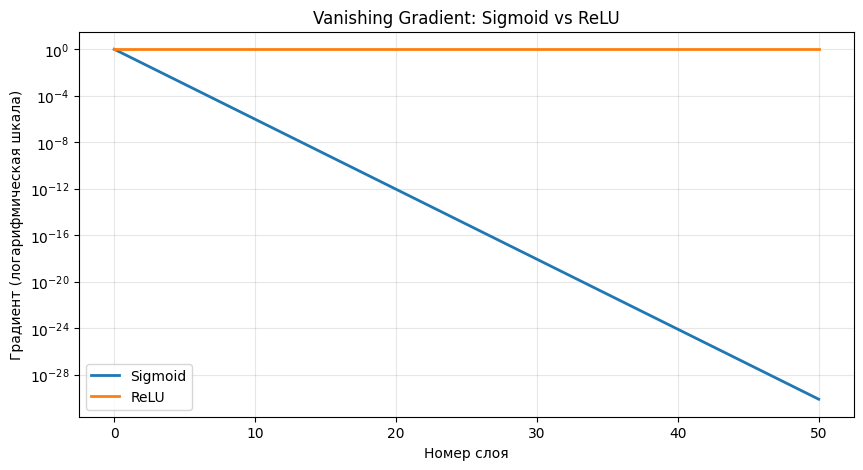

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_vanishing_gradient(n_layers, activation='sigmoid'):
    """
    Симуляция затухания градиента
    """
    if activation == 'sigmoid':
        derivative = 0.25  # максимальная производная сигмоиды
    elif activation == 'relu':
        derivative = 1.0   # производная ReLU для x>0
    else:
        derivative = 1.0
    
    grad = 1.0
    grads = [grad]
    
    for i in range(n_layers):
        grad = grad * derivative
        grads.append(grad)
    
    return grads

# Сравнение
layers = 50
sigmoid_grads = simulate_vanishing_gradient(layers, 'sigmoid')
relu_grads = simulate_vanishing_gradient(layers, 'relu')

print(f"Градиент после {layers} слоев:")
print(f"  Sigmoid: {sigmoid_grads[-1]:.2e}")
print(f"  ReLU:    {relu_grads[-1]:.2e}")

# Визуализация
plt.figure(figsize=(10, 5))
plt.plot(sigmoid_grads, label='Sigmoid', linewidth=2)
plt.plot(relu_grads, label='ReLU', linewidth=2)
plt.yscale('log')
plt.xlabel('Номер слоя')
plt.ylabel('Градиент (логарифмическая шкала)')
plt.title('Vanishing Gradient: Sigmoid vs ReLU')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Internal Covariate Shift (слайд 26)
Что это?
Изменение распределения входов слоя во время обучения (предыдущие слои меняют свои веса → меняются выходы → следующий слой постоянно видит новые данные).

Решение:
Batch Normalization (мы уже разбирали).

Вопрос 1: ReLU и взрыв градиента

ReLU не решает проблему взрыва, потому что производная = 1 не уменьшает градиент, но и не ограничивает его. Если градиент уже взорвался (стал огромным), ReLU просто передаст его дальше. Для борьбы со взрывом нужно активно ограничивать градиент (Gradient Clipping) или предотвращать его рост (He инициализация).

Вопрос 2: ResNet и vanishing
Твой ответ: "градиент перепрыгивает через слой" — это главная идея.


Обычный слой: x → f(x)
 ResNet-блок: x → f(x) + x

При обратном распространении:
∂(f(x)+x)/∂x = ∂f(x)/∂x + 1
Это +1 в градиенте гарантирует, что даже если ∂f(x)/∂x ≈ 0, градиент все равно будет хотя бы 1 → затухание предотвращено.

Вопрос 3: Gradient Clipping
Твой ответ правильный: взрыва.

Почему не затухания: Clipping обрезает большие градиенты, но не трогает маленькие. Для затухания нужно увеличивать градиент, а не обрезать.

Задача
Дано: Площадь дома (x1) и количество комнат (x2)
Нужно предсказать: Цену дома (y)

Это регрессия (не классификация).

In [4]:
import numpy as np

# Данные: [площадь, комнаты] → цена (в тыс.$)
X = np.array([
    [50, 1],   # маленький дом, 1 комната → 100 тыс.
    [80, 2],   # средний дом, 2 комнаты → 150 тыс.
    [100, 3],  # большой дом, 3 комнаты → 200 тыс.
    [120, 3],  # очень большой, 3 комнаты → 220 тыс.
    [150, 4],  # дом с 4 комнатами → 300 тыс.
])

y = np.array([100, 150, 200, 220, 300])

In [7]:
class LinearNeuron:
    def __init__(self, lr=0.0001):
        self.w1 = np.random.randn()*0.5
        self.w2 = np.random.randn()*0.5
        self.b = np.random.randn()
        
        self.lr = lr
        
    
    def forward(self, x1, x2):
        return self.w1 * x1 + self.w2*x2 + self.b
    
    def backward(self, x1, x2, y_true):
        # пока заглушка
        pass

    def train_step(self,x1,x2,y_true):
        y_pred = self.forward(x1,x2)

        error = y_pred - y_true

        self.w1 = self.w1 - self.lr *(2*error*x1)
        self.w2 = self.w2 - self.lr *(2*error*x2)
        self.b = self.b - self.lr * (2 * error)

        return y_pred


In [5]:
def mse_loss(y_pred,y_true):
    return np.mean((y_pred-y_true)**2)

In [6]:
print(mse_loss(5, 3))  # 4

4.0


In [8]:
X[:,0]

array([ 50,  80, 100, 120, 150])

In [9]:
y

array([100, 150, 200, 220, 300])

In [30]:
house = LinearNeuron(lr=8.6e-5)

for epoch in range(100):
    total_loss = 0
    for i in range(len(X)):
        y_pred = house.train_step(X[i,0],X[i,1],y[i])
        total_loss += mse_loss(y_pred,y)
    avg_loss = total_loss/len(X)

    if epoch % 10 == 0: 
        print(f"Эпоха {epoch}: loss = {avg_loss:.4f}")

Эпоха 0: loss = 15893.7101
Эпоха 10: loss = 6152.1250
Эпоха 20: loss = 6140.5426
Эпоха 30: loss = 6129.2048
Эпоха 40: loss = 6118.1089
Эпоха 50: loss = 6107.2523
Эпоха 60: loss = 6096.6323
Эпоха 70: loss = 6086.2462
Эпоха 80: loss = 6076.0914
Эпоха 90: loss = 6066.1653


In [31]:
print("Финальные веса:")
print(f"w1 (площадь) = {house.w1:.4f}")
print(f"w2 (комнаты) = {house.w2:.4f}")
print(f"bias = {house.b:.4f}")

Финальные веса:
w1 (площадь) = 3.8885
w2 (комнаты) = 0.9231
bias = -2.0129


In [32]:
print("\nПредсказания vs Реальность:")
for i in range(len(X)):
    pred = house.forward(X[i,0], X[i,1])
    print(f"Дом {i+1}: предсказано = {pred:.1f}, реально = {y[i]:.1f}, ошибка = {pred - y[i]:.1f}")


Предсказания vs Реальность:
Дом 1: предсказано = 193.3, реально = 100.0, ошибка = 93.3
Дом 2: предсказано = 310.9, реально = 150.0, ошибка = 160.9
Дом 3: предсказано = 389.6, реально = 200.0, ошибка = 189.6
Дом 4: предсказано = 467.4, реально = 220.0, ошибка = 247.4
Дом 5: предсказано = 585.0, реально = 300.0, ошибка = 285.0


In [33]:
class LinearNeuronWithReLU(LinearNeuron):
    def forward(self,x1,x2):
        z = self.w1*x1 + self.w2*x2 + self.b
        return max(0,z) # ReLU
    
    def train_step(self, x1, x2, y_true):
        y_pred = self.forward(x1,x2)

        error = y_pred - y_true

        z = self.w1*x1 + self.w2*x2 + self.b
        relu_grad = 1 if z > 0 else 0

        self.w1 = self.w1 - self.lr *(2*error*x1*relu_grad)
        self.w2 = self.w2 - self.lr *(2*error*x2*relu_grad)
        self.b = self.b - self.lr * (2 * error*relu_grad)

        return y_pred

In [34]:
house = LinearNeuronWithReLU(lr=8.6e-5)

for epoch in range(100):
    total_loss = 0
    for i in range(len(X)):
        y_pred = house.train_step(X[i,0],X[i,1],y[i])
        total_loss += mse_loss(y_pred,y)
    avg_loss = total_loss/len(X)

    if epoch % 10 == 0: 
        print(f"Эпоха {epoch}: loss = {avg_loss:.4f}")

Эпоха 0: loss = 14763.3733
Эпоха 10: loss = 6165.4935
Эпоха 20: loss = 6153.5053
Эпоха 30: loss = 6141.7664
Эпоха 40: loss = 6130.2741
Эпоха 50: loss = 6119.0256
Эпоха 60: loss = 6108.0184
Эпоха 70: loss = 6097.2495
Эпоха 80: loss = 6086.7165
Эпоха 90: loss = 6076.4165


In [9]:
import numpy as np

class TwoNeuronNetwork:
    def __init__(self, lr=0.0001):
        # Скрытый слой: 2 нейрона
        # Нейрон 1: веса w11, w12, смещение b1
        self.w11 = np.random.randn() * 0.5
        self.w12 = np.random.randn() * 0.5
        self.b1 = np.random.randn() * 0.1
        
        # Нейрон 2: веса w21, w22, смещение b2
        self.w21 = np.random.randn() * 0.5
        self.w22 = np.random.randn() * 0.5
        self.b2 = np.random.randn() * 0.1
        
        # Выходной слой: 1 нейрон (веса u1, u2, смещение c)
        self.u1 = np.random.randn() * 0.5
        self.u2 = np.random.randn() * 0.5
        self.c = np.random.randn() * 0.1
        
        self.lr = lr
    
    def forward(self, x1, x2):
        # Шаг 1: вычислить z1 и z2 (линейные комбинации)
        z1 = self.w11 * x1 + self.w12 * x2 + self.b1
        z2 = self.w21 * x1 + self.w22 * x2 + self.b2
        # Шаг 2: применить ReLU к z1 и z2 → h1, h2
        h1 = max(0,z1)
        h2 = max(0,z2)
        # Шаг 3: вычислить выход y_pred = u1*h1 + u2*h2 + c
        y_pred = self.u1*h1 + self.u2*h2 + self.c
        # Шаг 4: вернуть y_pred (и можешь вернуть h1, h2, z1, z2 для backward)
        return y_pred, h1, h2, z1, z2
    
    def relu_grad(self,z):
        return 1 if z > 0 else 0
    
    def train_step(self, x1, x2, y_true):
        # Шаг 1: forward (получить y_pred, h1, h2, z1, z2)
        y_pred, h1, h2, z1, z2 = self.forward(x1,x2)
        # Шаг 2: ошибка error = y_pred - y_true
        error = y_pred-y_true # Loss = (y_pred - y_true)^2
        # Шаг 3: градиенты для выходного слоя (du1, du2, dc)
        # ∂Loss/∂u1 = ∂Loss/∂y_pred * ∂y_pred/∂u1 = (2 * error) * h1
        du1 = 2* error * h1
        du2 = 2* error * h2
        dc = 2 * error
        # Шаг 4: градиенты для скрытого слоя с ReLU
        #    grad_h1 = error * u1 * (1 if z1 > 0 else 0)
        #    grad_h2 = error * u2 * (1 if z2 > 0 else 0)

        # ∂Loss/∂h1 = ∂Loss/∂y_pred * ∂y_pred/∂h1 = (2 * error) * u1
        # ∂Loss/∂z1 = ∂Loss/∂h1 * ∂h1/∂z1 = (2 * error) * u1 * relu_grad
        # Градиенты скрытого слоя
        relu_grad1 = 1 if z1 > 0 else 0
        relu_grad2 = 1 if z2 > 0 else 0
        
        dh1 = 2 * error * self.u1 * relu_grad1
        dh2 = 2 * error * self.u2 * relu_grad2
        # Шаг 5: градиенты для весов (dw11, dw12, db1, dw21, dw22, db2)

        # ∂Loss/∂w11 = ∂Loss/∂z1 * ∂z1/∂w11 = ∂Loss/∂z1 * x1
        dw11 = dh1 * x1
        dw12 = dh1 * x2
        db1 = dh1

        dw21 = dh2 * x1
        dw22 = dh2 * x2
        db2 = dh2

        # Шаг 6: обновить веса (self.xxx -= self.lr * dxxx)
        self.w11 -= self.lr * dw11
        self.w12 -= self.lr * dw12
        self.b1 -= self.lr * db1
        
        self.w21 -= self.lr * dw21
        self.w22 -= self.lr * dw22
        self.b2 -= self.lr * db2
        
        return y_pred

In [12]:
houses = TwoNeuronNetwork(lr=1e-5)

for epoch in range(200):
    total_loss = 0
    for i in range(len(X)):
        y_pred = houses.train_step(X[i,0],X[i,1],y[i])
        total_loss += (y_pred - y[i])**2
    if epoch % 20 == 0:
        avg_loss = total_loss / len(X)
        print(f"Эпоха {epoch}: loss = {avg_loss:.2f}")

Эпоха 0: loss = 11349.15
Эпоха 20: loss = 78.02
Эпоха 40: loss = 78.01
Эпоха 60: loss = 78.01
Эпоха 80: loss = 78.01
Эпоха 100: loss = 78.00
Эпоха 120: loss = 78.00
Эпоха 140: loss = 78.00
Эпоха 160: loss = 77.99
Эпоха 180: loss = 77.99


In [13]:
print("Финальные предсказания vs реальность:")
print("-" * 40)
for i in range(len(X)):
    y_pred, _, _, _, _ = houses.forward(X[i,0], X[i,1])
    print(f"Дом {i+1}: {X[i,0]}м², {X[i,1]} комн → предсказано {y_pred:.1f}, реально {y[i]:.1f}, ошибка {y_pred - y[i]:.1f}")

Финальные предсказания vs реальность:
----------------------------------------
Дом 1: 50м², 1 комн → предсказано 97.7, реально 100.0, ошибка -2.3
Дом 2: 80м², 2 комн → предсказано 156.2, реально 150.0, ошибка 6.2
Дом 3: 100м², 3 комн → предсказано 195.2, реально 200.0, ошибка -4.8
Дом 4: 120м², 3 комн → предсказано 234.1, реально 220.0, ошибка 14.1
Дом 5: 150м², 4 комн → предсказано 292.6, реально 300.0, ошибка -7.4


In [15]:
import numpy as np

class ThreeNeuronNetwork:
    def __init__(self, lr=0.0001):
        # Скрытый слой: 3 нейрона
        # Нейрон 1: веса w11, w12, смещение b1
        self.w11 = np.random.randn() * 0.5
        self.w12 = np.random.randn() * 0.5
        self.b1 = np.random.randn() * 0.1
        
        # Нейрон 2: веса w21, w22, смещение b2
        self.w21 = np.random.randn() * 0.5
        self.w22 = np.random.randn() * 0.5
        self.b2 = np.random.randn() * 0.1

        # Нейрон 3: веса w31, w32, смещение b3
        self.w31 = np.random.randn() * 0.5
        self.w32 = np.random.randn() * 0.5
        self.b3 = np.random.randn() * 0.1
        
        # Выходной слой: 1 нейрон (веса u1, u2, смещение c)
        self.u1 = np.random.randn() * 0.5
        self.u2 = np.random.randn() * 0.5
        self.u3 = np.random.randn() * 0.5
        self.c = np.random.randn() * 0.1
        
        self.lr = lr
    
    def forward(self, x1, x2):
        # Шаг 1: вычислить z1 и z2 (линейные комбинации)
        z1 = self.w11 * x1 + self.w12 * x2 + self.b1
        z2 = self.w21 * x1 + self.w22 * x2 + self.b2
        z3 = self.w31 * x1 + self.w32 * x2 + self.b3
        # Шаг 2: применить ReLU к z1 и z2 → h1, h2
        h1 = max(0,z1)
        h2 = max(0,z2)
        h3 = max(0,z3)
        # Шаг 3: вычислить выход y_pred = u1*h1 + u2*h2 + c
        y_pred = self.u1*h1 + self.u2*h2 + self.u3*h3 + self.c
        # Шаг 4: вернуть y_pred (и можешь вернуть h1, h2, z1, z2 для backward)
        return y_pred, h1, h2,h3, z1, z2,z3
    
    def relu_grad(self,z):
        return 1 if z > 0 else 0
    
    def train_step(self, x1, x2, y_true):
        # Шаг 1: forward (получить y_pred, h1, h2, z1, z2)
        y_pred, h1, h2,h3, z1, z2,z3 = self.forward(x1,x2)
        # Шаг 2: ошибка error = y_pred - y_true
        error = y_pred-y_true # Loss = (y_pred - y_true)^2
        # Шаг 3: градиенты для выходного слоя (du1, du2, dc)
        # ∂Loss/∂u1 = ∂Loss/∂y_pred * ∂y_pred/∂u1 = (2 * error) * h1
        du1 = 2* error * h1
        du2 = 2* error * h2
        du3 = 2 * error * h3
        dc = 2 * error
        # Шаг 4: градиенты для скрытого слоя с ReLU
        #    grad_h1 = error * u1 * (1 if z1 > 0 else 0)
        #    grad_h2 = error * u2 * (1 if z2 > 0 else 0)

        # ∂Loss/∂h1 = ∂Loss/∂y_pred * ∂y_pred/∂h1 = (2 * error) * u1
        # ∂Loss/∂z1 = ∂Loss/∂h1 * ∂h1/∂z1 = (2 * error) * u1 * relu_grad
        # Градиенты скрытого слоя
        relu_grad1 = 1 if z1 > 0 else 0
        relu_grad2 = 1 if z2 > 0 else 0
        relu_grad3 = 1 if z3 > 0 else 0

        dh1 = 2 * error * self.u1 * relu_grad1
        dh2 = 2 * error * self.u2 * relu_grad2
        dh3 = 2 * error * self.u3 * relu_grad3
        # Шаг 5: градиенты для весов (dw11, dw12, db1, dw21, dw22, db2)

        # ∂Loss/∂w11 = ∂Loss/∂z1 * ∂z1/∂w11 = ∂Loss/∂z1 * x1
        dw11 = dh1 * x1
        dw12 = dh1 * x2
        db1 = dh1

        dw21 = dh2 * x1
        dw22 = dh2 * x2
        db2 = dh2

        dw31 = dh3 * x1
        dw32 = dh3 * x2
        db3 = dh3

        # Шаг 6: обновить веса (self.xxx -= self.lr * dxxx)
        self.w11 -= self.lr * dw11
        self.w12 -= self.lr * dw12
        self.b1 -= self.lr * db1
        
        self.w21 -= self.lr * dw21
        self.w22 -= self.lr * dw22
        self.b2 -= self.lr * db2

        self.w31 -= self.lr * dw31
        self.w32 -= self.lr * dw32
        self.b3 -= self.lr * db3
        
        return y_pred

In [27]:
model = ThreeNeuronNetwork(lr=1.5e-5)

for epoch in range(200):
    total_loss = 0
    for i in range(len(X)):
        y_pred = model.train_step(X[i,0], X[i,1], y[i])
        total_loss += (y_pred - y[i])**2
    if epoch % 20 == 0:
        avg_loss = total_loss / len(X)
        print(f"Эпоха {epoch}: loss = {avg_loss:.2f}")

# Проверка предсказаний
print("\nФинальные предсказания:")
for i in range(len(X)):
    y_pred, _, _, _, _, _, _ = model.forward(X[i,0], X[i,1])
    print(f"Дом {i+1}: предсказано {y_pred:.1f}, реально {y[i]:.1f}")

Эпоха 0: loss = 26340.74
Эпоха 20: loss = 68.51
Эпоха 40: loss = 67.40
Эпоха 60: loss = 67.40
Эпоха 80: loss = 67.40
Эпоха 100: loss = 67.40
Эпоха 120: loss = 67.40
Эпоха 140: loss = 67.40
Эпоха 160: loss = 67.40
Эпоха 180: loss = 67.39

Финальные предсказания:
Дом 1: предсказано 97.3, реально 100.0
Дом 2: предсказано 155.6, реально 150.0
Дом 3: предсказано 194.5, реально 200.0
Дом 4: предсказано 233.4, реально 220.0
Дом 5: предсказано 291.7, реально 300.0


In [29]:
X,y

(array([[ 50,   1],
        [ 80,   2],
        [100,   3],
        [120,   3],
        [150,   4]]),
 array([100, 150, 200, 220, 300]))

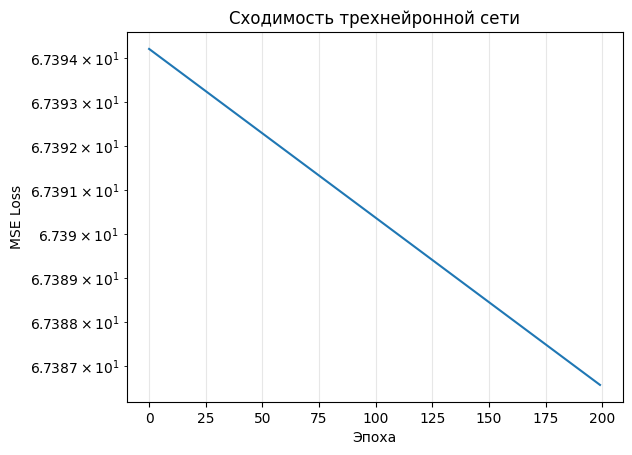

In [28]:
import matplotlib.pyplot as plt

# Собери loss в список во время обучения
losses = []
for epoch in range(200):
    total_loss = 0
    for i in range(len(X)):
        y_pred = model.train_step(X[i,0], X[i,1], y[i])
        total_loss += (y_pred - y[i])**2
    losses.append(total_loss / len(X))

plt.plot(losses)
plt.xlabel('Эпоха')
plt.ylabel('MSE Loss')
plt.title('Сходимость трехнейронной сети')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

Вопрос 1: Почему loss для 3 нейронов начался выше?

Loss считается одинаково для 2 и 3 нейронов — по выходу сети, а не по нейронам.

Начальные веса случайные. При 3 нейронах случайность может дать более неудачную комбинацию весов, чем при 2 нейронах. Поэтому стартовый loss выше. Если перезапустить несколько раз, цифры будут разными.

Вопрос 2: Что будет с 10 нейронами?
Твой ответ: "для тренировочных данных да, для тестовых нет — переобучение"

✅ Абсолютно правильно!

Добавлю: На 5 точках данных 10 нейронов — это катастрофа. Сеть запомнит данные (loss ~0), но на новом доме предскажет ерунду.

Вопрос 3: Почему дом 4 предсказан хуже всего?
Твой ответ: "не хватило тренировочной выборки"

Это часть правды. Добавлю конкретики:
Дом 4 нелогичен по сравнению с домом 5:

Дом 5: 150м², 4 комнаты → 300 (2 тыс. за м²)

Дом 4: 120м², 3 комнаты → 220 (1.83 тыс. за м²)

Сетям сложно выучить такие аномалии на 5 примерах.